# Environment Setup

In [1]:
# %pip install torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import seaborn as sns
# %pip install colorcet
import colorcet as cc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from scipy import interpolate
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import *
# %pip install captum
import captum
# %pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patheffects import withStroke
import scipy.io
import h5py
import math
import random
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams["mathtext.fontset"]= 'cm'  # Use Computer Modern for math
plt.rc('axes', labelsize=28, titlesize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)

In [ ]:
#### For local runtime and local data files:
%cd C:/path/to/data/folder

F:\1_Caltech\Research-Local\Sensor_datasets\Channel_data


## Utility Functions

In [4]:
def normalize_01(data):
    data_min = np.min(data, axis=0)
    data_max = np.max(data, axis=0)
    data_scaled = (data - data_min) / (data_max - data_min)
    return data_scaled, data_min, data_max

def unnormalize_01(data_scaled, data_min, data_max):
    return data_scaled * (data_max - data_min) + data_min

def normalize_m1_1(data):
    data_mean = np.mean(data, axis=0)
    max_range = np.max(np.abs(data - data_mean), axis=0)
    data_scaled = (data - data_mean) / max_range
    return data_scaled, data_mean, max_range

def unnormalize_m1_1(data_scaled, data_mean, max_range):
    return data_scaled * max_range + data_mean

def normalize_utau(data, utau, scale=0.1, square=False):
    data_mean = np.mean(data, axis=0)
    denom = utau**2 if square else utau
    data_scaled = scale * (data - data_mean) / denom
    return data_scaled, data_mean

def unnormalize_utau(data_scaled, data_mean, utau, scale=0.1, square=False):
    denom = utau**2 if square else utau
    return data_scaled * denom / scale + data_mean

def normalize_utau_01(data, utau, scale=1.0, square=False):
    # Step 1: Normalize by u_tau
    data_mean = np.mean(data, axis=0)
    denom = utau**2 if square else utau
    data_utau = scale * (data - data_mean) / denom

    # Step 2: Normalize to [0, 1]
    data_min = np.min(data_utau, axis=0)
    data_max = np.max(data_utau, axis=0)
    data_scaled = (data_utau - data_min) / (data_max - data_min)

    return data_scaled, data_mean, data_min, data_max

def unnormalize_utau_01(data_scaled, data_mean, data_min, data_max, utau, scale=1.0, square=False):
    # Step 1: Unscale from [0, 1]
    data_utau = data_scaled * (data_max - data_min) + data_min

    # Step 2: Unnormalize from u_tau
    denom = utau**2 if square else utau
    data_original = data_utau * denom / scale + data_mean

    return data_original

# Data Setup

In [5]:
# Choose normalization method: "01" for [0,1]; "m11" for [-1,1]; "u_tau" for dimensionless
normalization = "m11"

# Load Datasets
nu = 3.076923076923077e-04
utau = 0.057231
Retau = 186
dt_plus = utau**2/nu*0.1
with h5py.File('V_data.mat', 'r') as file:
  V_raw = file['V_data'][()].T # Access the 'V_probe' dataset and convert to NumPy array
with h5py.File('P_w.mat', 'r') as file:
  P_w_raw = file['P_w'][()].T # Access the 'V_probe' dataset and convert to NumPy array
# (nt, nx, ny, nz)

ix_list = range(200) # X indices of wall shear stress probes
iy_list = 22 # y+=10
iz_list = range(40)


data = scipy.io.loadmat('x_edge.mat')
x_edge = data['x']
data = scipy.io.loadmat('y_edge.mat')
y_edge = data['y']
data = scipy.io.loadmat('z_edge.mat')
z_edge = data['z']

x_plus = x_edge[ix_list]*Retau
y_plus = y_edge*Retau
z_plus = z_edge[iz_list]*Retau

nt,nx,ny,nz = V_raw.shape
print(V_raw.shape)
print(P_w_raw.shape)
print(x_edge.shape)
print(y_edge.shape)
print(z_edge.shape)
print(x_plus.shape)
print(y_plus.shape)
print(z_plus.shape)

(900, 200, 66, 40)
(900, 200, 40)
(1026, 1)
(131, 1)
(386, 1)
(200, 1)
(131, 1)
(40, 1)


In [6]:
V_xz = V_raw[:,:,iy_list,:] # xz slice of V at y+=9.6
ix_samples = np.arange(10,200,10) # X indices of velocity probes
iz_samples = np.arange(10,40,10)  # Z indices of velocity probes
x_window = 9 # how many grid points to consider in one direction
z_window = 9

# sample and stack probe and target data
P_w_probe_raw  = np.zeros((0,x_window*2+1,z_window*2+1))
V_probe_raw = np.zeros((0))

for ix in ix_samples:
  for iz in iz_samples:
    V_probe_raw = np.concatenate((V_probe_raw,V_xz[:,ix,iz]))
    P_w_probe_raw = np.concatenate((P_w_probe_raw,P_w_raw[:,ix-x_window:ix+x_window+1,iz-z_window:iz+z_window+1]),axis=0)
print("V_probe_raw", V_probe_raw.shape)
print("P_w_probe_raw", P_w_probe_raw.shape)

V_probe_raw (51300,)
P_w_probe_raw (51300, 19, 19)


In [7]:
n_points, n_xprobe, n_zprobe = P_w_probe_raw.shape
print('n_points =',n_points)
n_probe = n_xprobe*n_zprobe
print('n_probe =',n_probe)

dx = np.ediff1d(x_plus)[0]
dz = dx

X_probe = np.arange(-x_window, x_window+1,)*dx
Z_probe = np.arange(-z_window, z_window+1)*dz

x_grid, z_grid = np.meshgrid(X_probe, Z_probe) # (nz,nx) reverse dimensions
x_flatten = x_grid.reshape(n_probe)
z_flatten = z_grid.reshape(n_probe)
P_flatten = P_w_probe_raw.reshape(n_points,n_probe,order='F')
print('n_probe =',n_probe)

n_points = 51300
n_probe = 361
n_probe = 361


In [8]:
# # For [0, 1] normalization
if normalization == "01":
  P_scaled, P_min, P_max = normalize_01(P_flatten)
  V_scaled, V_min, V_max = normalize_01(V_probe_raw)
elif normalization == "m11":
  # For [-1, 1] normalization
  P_scaled, P_mean, P_range = normalize_m1_1(P_flatten)
  V_scaled, V_mean, V_range = normalize_m1_1(V_probe_raw)
elif normalization == "u_tau":
  # For u_tau normalization
  P_scaled, P_mean = normalize_utau(P_flatten, utau, scale=0.1, square=True)
  V_scaled, V_mean = normalize_utau(V_probe_raw, utau, scale=1.0, square=False)
elif normalization == "u_tau_01":
  # Normalize V using u_tau and then to [0,1]
  P_scaled, P_mean, P_min, P_max = normalize_utau_01(P_flatten, utau, scale=1.0, square=True)
  V_scaled, V_mean, V_min, V_max = normalize_utau_01(V_probe_raw, utau, scale=1.0, square=False)
elif normalization == "standard":
  # For standard normalization
  scaler = StandardScaler()
  P_scaled = scaler.fit_transform(P_flatten)
  V_scaled = scaler.fit_transform(V_probe_raw.reshape(-1, 1)).reshape(-1)

In [11]:
P_eval = P_scaled[26100:27000,:]
V_eval = V_scaled[26100:27000]

# remove the evaluation points from P_scaled and V_scaled
P_scaled_train = np.delete(P_scaled, np.s_[26100:27000], axis=0)
V_scaled_train = np.delete(V_scaled, np.s_[26100:27000])

print(P_scaled_train.shape)
print(V_scaled_train.shape)
print(P_eval.shape)
print(V_eval.shape)

(50400, 361)
(50400,)
(900, 361)
(900,)


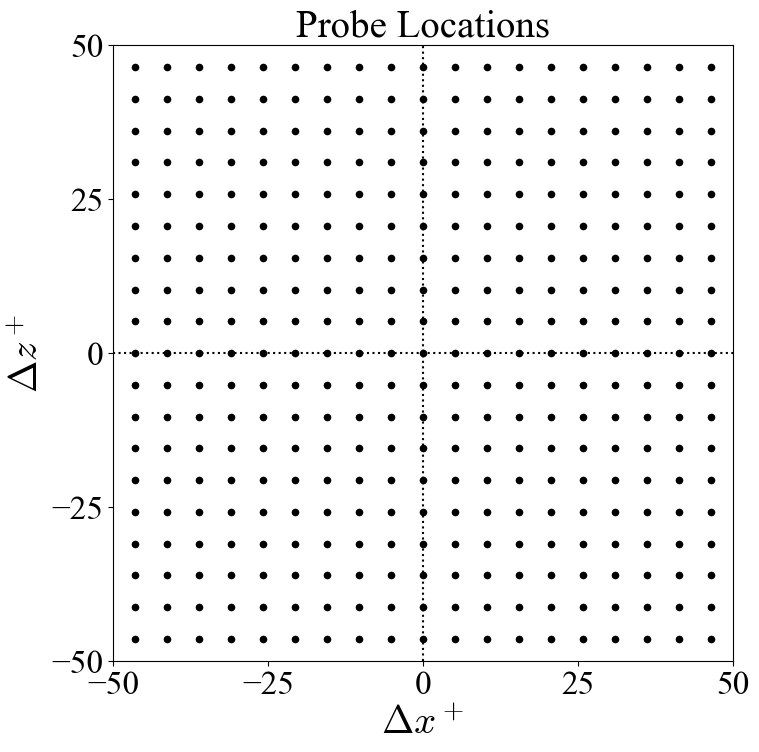

In [12]:
fig = plt.figure(figsize=(8,8))
plt.rc('axes', labelsize=28, titlesize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)

# Create scatter plots for all points
plt.scatter(x_flatten, z_flatten, s=20, marker='o', c='black')
plt.axvline(x=0, color='black', linestyle=':')
plt.axhline(y=0, color='black', linestyle=':')

plt.ylim([-50,50])
plt.yticks([-50,-25,0,25,50])
plt.xlim([-50,50])
plt.xticks([-50,-25,0,25,50])
plt.xlabel('$\Delta x^+$')
plt.ylabel('$\Delta z^+$')
plt.title('Probe Locations')
#plt.savefig("clusters_map.png",format='png',bbox_inches='tight')
plt.show()

## Compute time-lagged cross-correlation

Dimensionless time lag: -5.3225


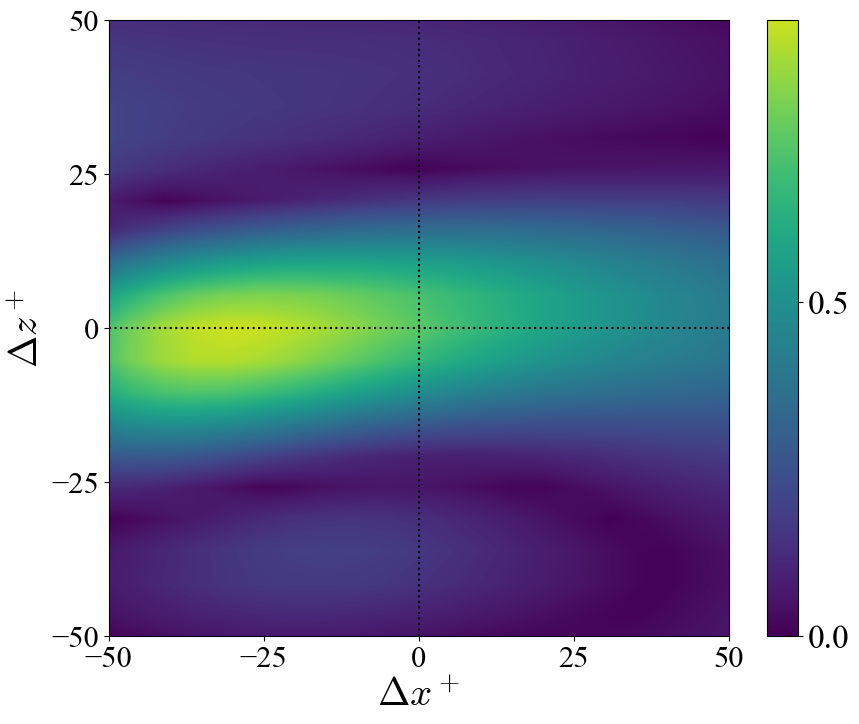

In [13]:
import scipy.signal

# MATLAB-equivalent xcorr function
def xcorr(x, y, maxlag):
    """
    Replicates MATLAB's xcorr(x, y, maxlag, 'coeff').
    Computes the cross-correlation of 1D arrays x and y.
    """
    # 'full' computes for all possible lags
    c = np.correlate(x, y, mode='full')

    # The zero-lag position is at len(y) - 1
    center = len(y) - 1

    # Slice the result to match the -maxlag to +maxlag range
    c_sliced = c[center - maxlag : center + maxlag + 1]

    # Normalize to get the 'coeff' equivalent
    norm_factor = np.sqrt(np.sum(x**2) * np.sum(y**2))
    if norm_factor == 0:
        return np.zeros(2 * maxlag + 1)

    return c_sliced / norm_factor

# Parameters & Setup
xz_window = 10
ix_samples = np.arange(10, 185, 11)

# Time-Lag
max_tlag = 50        # Maximum time lag to compute (+/-)
lag_plot = -5        # Specific time lag step to plot

x_coord = np.arange(-xz_window, xz_window + 1)
x_plus_coord = x_coord * dx * Retau
z_plus_coord = x_plus_coord

detrend_data = False

Nx_window = len(x_coord)
Nz_window = len(x_coord)
N_lags = 2 * max_tlag + 1  # Total number of lags computed

# Compute fluctuations (subtract global mean)
P_w = P_w_raw - np.mean(P_w_raw)
V = V_raw[:, :, iy_list, :]
V = V - np.mean(V)

# Computing X-Corr
# Initialize as 3D array: (Lags, Nx, Nz)
CrossCorr_mean = np.zeros((N_lags, Nx_window, Nz_window))

for ix in ix_samples:
    CrossCorr = np.zeros((N_lags, Nx_window, Nz_window))

    ix_start = ix - xz_window
    ix_end = ix + xz_window + 1

    iz_start = 19 - xz_window
    iz_end = 19 + xz_window + 1

    P_w_sub = P_w[:, ix_start:ix_end, iz_start:iz_end]
    V_sub = V[:, ix, 19]

    if detrend_data:
        V_sub = scipy.signal.detrend(V_sub)
        P_w_sub = scipy.signal.detrend(P_w_sub, axis=0)

    for i in range(Nx_window):
        for j in range(Nz_window):
            P_t = P_w_sub[:, i, j]

            # Compute time-lagged cross-correlation
            R_utau = xcorr(P_t, V_sub, max_tlag)
            CrossCorr[:, i, j] = R_utau

    # Accumulate for averaging
    CrossCorr_mean += CrossCorr

# Average over x samples
CrossCorr_mean = CrossCorr_mean / len(ix_samples)

# Normalize and take magnitude over the entire 3D volume
CrossCorr_mean = np.abs(CrossCorr_mean) / np.max(np.abs(CrossCorr_mean))

# Save full 3D data
# np.save('CrossCorr_mean.npy', CrossCorr_mean)

# Plot X-Corr contour at specified lag
# Generate spatial grid
Xgrid, Zgrid = np.meshgrid(x_plus_coord, z_plus_coord)

# Determine the index of the requested lag_plot
if not (-max_tlag <= lag_plot <= max_tlag):
    raise ValueError(f"lag_plot must be between {-max_tlag} and {max_tlag}")

lag_idx = max_tlag + lag_plot
physical_time_lag = lag_plot * dt_plus
print(f"Dimensionless time lag: {physical_time_lag:.4f}")

fig = plt.figure(figsize=(10, 8))
plt.axvline(x=0, color='black', linestyle=':')
plt.axhline(y=0, color='black', linestyle=':')

x_plus_list = np.arange(-10,11)*dx
Xgrid, Zgrid = np.meshgrid(x_plus_list, x_plus_list)
contour = plt.contourf(Xgrid, Zgrid, CrossCorr_mean[lag_idx, :, :].T, levels=500, linestyles='none',cmap='viridis')
contour.set_edgecolor("face") # make sure there's no contours lines in AI

plt.colorbar(contour, ticks=[0, 0.5, 1])
plt.clim(0, 1)  # Set color limits

plt.ylim([-50,50])
plt.yticks([-50,-25,0,25,50])
plt.xlim([-50,50])
plt.xticks([-50,-25,0,25,50])
plt.xlabel('$\Delta x^+$')
plt.ylabel('$\Delta z^+$')
plt.tick_params(axis='both', labelsize=22)
# plt.savefig("PV_sensors_4config.png",format='png',dpi=600)
# plt.savefig("PV_sensors_4config.pdf",format='pdf',bbox_inches='tight')
plt.show()

# Bayes OED Method

In [ ]:
# Configuration

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

epsilon = 0.01 # controls greedy optimization sample size
V_bins = 25  # Defining number of bins for the target variable
n_mc_outer = 20000
n_mc_inner = 4000
p_sensors = 10  # Choose the target number of sensors to select
sensor_noise_variance = 0.005 # added variance parameter to reduce sensor clustering

bin_edges = np.quantile(V_scaled_train, np.linspace(0, 1, V_bins + 1))
bin_edges[0] -= 1e-5  # slightly extend the lower limit to include the minimum
V_binned = np.digitize(V_scaled_train, bin_edges) - 1
V_binned = np.clip(V_binned, 0, V_bins - 1)

P_data = torch.tensor(P_scaled_train, dtype=torch.float32, device=device)
V_data = torch.tensor(V_binned, dtype=torch.int64, device=device)

n_total_candidates = P_data.shape[1]


# ==========================================
# compute means and covariances
mu_bins = torch.zeros((V_bins, n_total_candidates), device=device)

# Initialize with a diagonal noise matrix instead of zeros
base_cov = torch.eye(n_total_candidates, device=device) * sensor_noise_variance
cov_bins = base_cov.unsqueeze(0).repeat(V_bins, 1, 1)

for b in range(V_bins):
    mask = (V_data == b)
    if mask.sum() > 1:
        P_bin = P_data[mask]
        mu_bins[b] = P_bin.mean(dim=0)
        # Overwrite the default baseline with actual covariance + noise
        cov_bins[b] = torch.cov(P_bin.T) + base_cov
    elif mask.sum() == 1:
        # If exactly 1 sample happens (rare with quantiles, but safe), just set the mean
        mu_bins[b] = P_data[mask].squeeze(0)

# NMC with Importance Sampling (EIG)
def compute_EIG(candidate_sensor, selected_sensors):
    """
    Computes EIG using Nested Monte Carlo with Importance Sampling.
    """
    active_sensors = selected_sensors + [candidate_sensor]

    # Extract sub-matrices for the currently active sensors
    mu_active = mu_bins[:, active_sensors]                         # (V_bins, n_active)
    cov_active = cov_bins[:, active_sensors][:, :, active_sensors] # (V_bins, n_active, n_active)

    # Create batched Multivariate Normal distribution for likelihood evaluations
    likelihood_dist = torch.distributions.MultivariateNormal(mu_active, cov_active)

    # OUTER LOOP: Sample N parameter bins from the prior (uniform over bins)
    theta_outer = torch.randint(0, V_bins, (n_mc_outer,), device=device)

    # Sample observation Y from p(Y | theta_outer)
    y_outer = likelihood_dist.sample((n_mc_outer,))
    y_outer = y_outer[torch.arange(n_mc_outer), theta_outer, :]

    # Compute log p(Y | theta_outer)
    log_p_y_given_theta_outer = likelihood_dist.log_prob(y_outer.unsqueeze(1))
    log_p_y_given_theta_outer = log_p_y_given_theta_outer[torch.arange(n_mc_outer), theta_outer]

    # INNER LOOP with IMPORTANCE SAMPLING:
    # Bias inner samples to be close to the outer sample (e.g., adjacent bins)
    is_mask = torch.rand((n_mc_outer, n_mc_inner), device=device) < 0.8
    theta_inner_random = torch.randint(0, V_bins, (n_mc_outer, n_mc_inner), device=device)
    theta_inner = torch.where(is_mask, theta_outer.unsqueeze(1).expand(-1, n_mc_inner), theta_inner_random)

    # Compute Importance Weights: w = p(theta) / q(theta)
    p_theta = 1.0 / V_bins
    q_theta = torch.where(theta_inner == theta_outer.unsqueeze(1),
                          0.8 + 0.2 * p_theta,
                          0.2 * p_theta * torch.ones_like(theta_inner, dtype=torch.float32))
    weights = p_theta / q_theta

    # Compute log p(Y | theta_inner)
    log_p_y_given_theta_inner = likelihood_dist.log_prob(y_outer.unsqueeze(1))

    # Gather the likelihoods for the specific inner samples
    inner_likelihoods = log_p_y_given_theta_inner.gather(1, theta_inner)

    # Estimate evidence: 1/M * sum( L * weights )
    weighted_likelihoods = torch.exp(inner_likelihoods) * weights
    evidence = weighted_likelihoods.mean(dim=1)
    log_evidence = torch.log(evidence + 1e-10) # Avoid log(0)

    # EIG = mean( log p(Y|theta) - log p(Y) )
    eig = (log_p_y_given_theta_outer - log_evidence).mean().item()
    return eig

# Stochastic Greedy Optimization
selected_sensors = []
candidates = list(range(n_total_candidates))

# Subsample size formula R = (|V| / p) * log(1/epsilon)
subset_size = min(len(candidates), math.ceil((len(candidates) / p_sensors) * math.log(1 / epsilon)))

print(f"Starting optimization. Subset size per step: {subset_size} / {len(candidates)}")

for q in range(p_sensors):
    # Stochastic Greedy: Evaluate only a random subset of available candidates
    random_subset = random.sample(candidates, subset_size)

    best_u = -float('inf')
    best_s = -1

    for s in random_subset:
        u = compute_EIG(s, selected_sensors)
        if u > best_u:
            best_u = u
            best_s = s

    selected_sensors.append(best_s)
    candidates.remove(best_s)
    print(f"Step {q+1}/{p_sensors} | Selected Sensor: {best_s} | EIG: {best_u:.4f}")

print("\nFinal Optimal Sensors:", selected_sensors)

Using device: cuda
Starting optimization. Subset size per step: 167 / 361
Step 1/10 | Selected Sensor: 187 | EIG: 0.0687
Step 2/10 | Selected Sensor: 72 | EIG: 0.0999
Step 3/10 | Selected Sensor: 183 | EIG: 0.1353
Step 4/10 | Selected Sensor: 216 | EIG: 0.1716
Step 5/10 | Selected Sensor: 263 | EIG: 0.2050
Step 6/10 | Selected Sensor: 139 | EIG: 0.2311
Step 7/10 | Selected Sensor: 208 | EIG: 0.2509
Step 8/10 | Selected Sensor: 318 | EIG: 0.2704
Step 9/10 | Selected Sensor: 135 | EIG: 0.2853
Step 10/10 | Selected Sensor: 181 | EIG: 0.2967

Final Optimal Sensors: [187, 72, 183, 216, 263, 139, 208, 318, 135, 181]


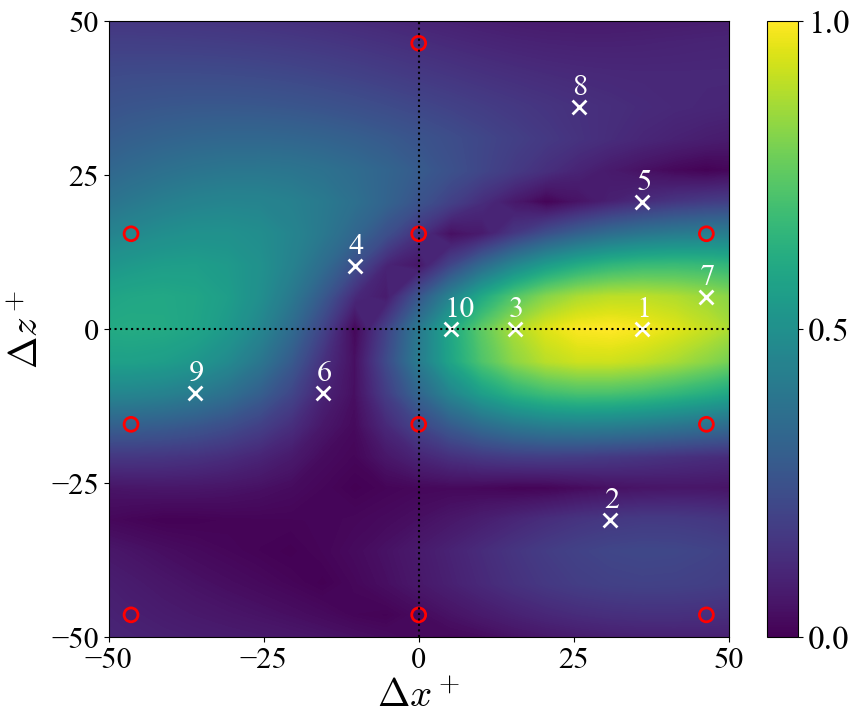

In [ ]:
# attr_sensors = np.array([208, 197, 181, 192, 29]) # 20 CAAF sensors with best pred
attr_sensors = selected_sensors
attr_sensors2 = np.array([0,   9,  18, 114, 123, 132, 228, 237, 246, 351])  # evenly spaced

fig = plt.figure(figsize=(10, 8))
# Create scatter plots for all points
plt.axvline(x=0, color='black', linestyle=':')
plt.axhline(y=0, color='black', linestyle=':')

# Add X-corr
data = scipy.io.loadmat('CrossCorr_mean.mat')
CrossCorr_mean = data['CrossCorr_mean']
x_plus_list = np.arange(-10,11)*dx
Xgrid, Zgrid = np.meshgrid(x_plus_list, x_plus_list)
contour = plt.contourf(Xgrid, Zgrid, CrossCorr_mean.T, levels=500, linestyles='none',cmap='viridis')
contour.set_edgecolor("face") # make sure there's no contours lines in AI

plt.colorbar(contour, ticks=[0, 0.5, 1])
plt.clim(0, 1)  # Set color limits

for j in attr_sensors2[:10]:
  plt.scatter(x_flatten[j], z_flatten[j], marker='o', s=100, facecolors='none', color='red', linewidth=2)

rank = 1
for i in attr_sensors[:10]:
  plt.scatter(x_flatten[i], z_flatten[i], marker='x', s=100, color='white', linewidth=2)
  annotation = plt.annotate(str(rank), (x_flatten[i]-1, z_flatten[i]+2), fontsize=22, color='white')
  rank += 1

plt.ylim([-50,50])
plt.yticks([-50,-25,0,25,50])
plt.xlim([-50,50])
plt.xticks([-50,-25,0,25,50])
plt.xlabel('$\Delta x^+$')
plt.ylabel('$\Delta z^+$')
# plt.gca().set_aspect('equal', adjustable='datalim')
plt.tick_params(axis='both', labelsize=22)
# plt.savefig("PV_sensors.png",format='png',dpi=600)
# plt.savefig("PV_sensors.pdf",format='pdf',bbox_inches='tight')
plt.show()

# POD Method

In [ ]:
from scipy.linalg import qr

# Assume P_scaled_train is loaded as shape (n_snapshots, n_candidates)
P_data = np.array(P_scaled_train)
p_sensors = 5

def pod_qr_sensor_placement(data, p):
    data_centered = data - np.mean(data, axis=0)

    _, _, Vt = np.linalg.svd(data_centered, full_matrices=False)
    modes_p = Vt.T[:, :p]

    _, _, pivot = qr(modes_p.T, pivoting=True)

    return pivot[:p].tolist()

selected_pod_sensors = pod_qr_sensor_placement(P_data, p_sensors)
print("Optimal Sensors (POD-QR):", selected_pod_sensors)

Optimal Sensors (POD-QR): [355, 326, 71, 60, 199]


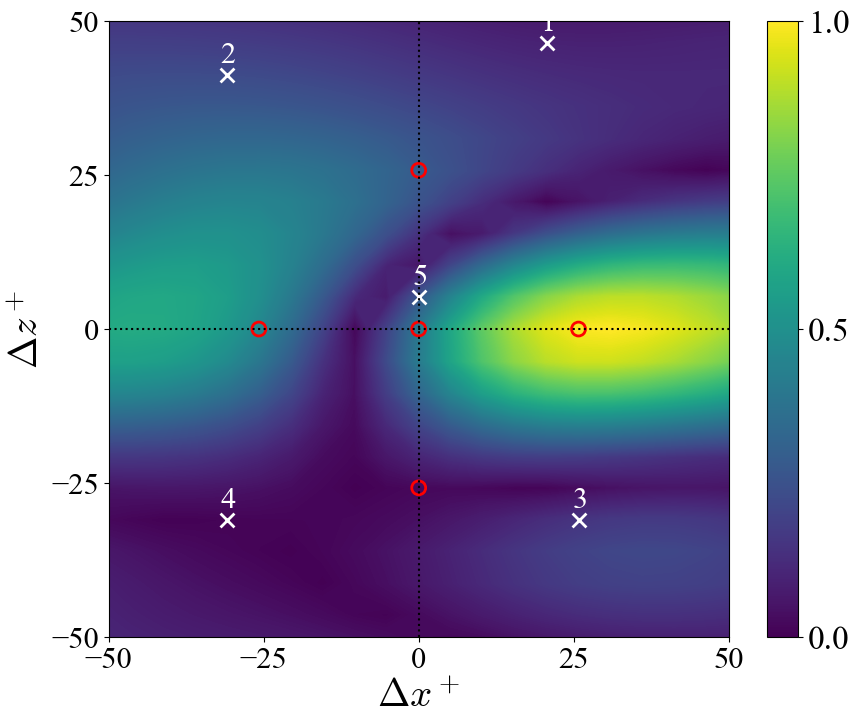

In [ ]:
# attr_sensors = np.array([208, 197, 181, 192, 29]) # 20 CAAF sensors with best pred
attr_sensors = selected_pod_sensors
# attr_sensors2 = np.array([0,   9,  18, 114, 123, 132, 228, 237, 246, 351])  # 10 evenly spaced
attr_sensors2 = np.array([185,275,85,175,180])  # 5 evenly spaced

fig = plt.figure(figsize=(10, 8))
# Create scatter plots for all points
plt.axvline(x=0, color='black', linestyle=':')
plt.axhline(y=0, color='black', linestyle=':')

# Add X-corr
data = scipy.io.loadmat('CrossCorr_mean.mat')
CrossCorr_mean = data['CrossCorr_mean']
x_plus_list = np.arange(-10,11)*dx
Xgrid, Zgrid = np.meshgrid(x_plus_list, x_plus_list)
contour = plt.contourf(Xgrid, Zgrid, CrossCorr_mean.T, levels=500, linestyles='none',cmap='viridis')
contour.set_edgecolor("face") # make sure there's no contours lines in AI

plt.colorbar(contour, ticks=[0, 0.5, 1])
plt.clim(0, 1)  # Set color limits

# # Remove edge artifacts from contour polygons
# for c in contour.collections:
#     c.set_edgecolor("face")

for j in attr_sensors2[:10]:
  plt.scatter(x_flatten[j], z_flatten[j], marker='o', s=100, facecolors='none', color='red', linewidth=2)

rank = 1
for i in attr_sensors[:10]:
  plt.scatter(x_flatten[i], z_flatten[i], marker='x', s=100, color='white', linewidth=2)
  annotation = plt.annotate(str(rank), (x_flatten[i]-1, z_flatten[i]+2), fontsize=22, color='white')
  rank += 1

plt.ylim([-50,50])
plt.yticks([-50,-25,0,25,50])
plt.xlim([-50,50])
plt.xticks([-50,-25,0,25,50])
plt.xlabel('$\Delta x^+$')
plt.ylabel('$\Delta z^+$')
# plt.gca().set_aspect('equal', adjustable='datalim')
plt.tick_params(axis='both', labelsize=22)
# plt.savefig("PV_sensors.png",format='png',dpi=600)
# plt.savefig("PV_sensors.pdf",format='pdf',bbox_inches='tight')
plt.show()

# Remove Correlated Sensors

In [ ]:
# AffinityPropagation Clustering
aff_matrix = np.abs(np.corrcoef(P_flatten.T)) # Compute affinity matrix using correlation coefficient
af = AffinityPropagation(damping=0.5,max_iter=10000, convergence_iter=50, copy=True, preference= 0.9, affinity='precomputed').fit(aff_matrix)
cluster_centers_indices = af.cluster_centers_indices_
labels = af.labels_
n_clusters_ = len(set(labels))
# sensors = cluster_centers_indices
print('n_clusters =',n_clusters_)

# np.save('PV_cluster_centers_indices.npy', cluster_centers_indices)
# np.save('PV_labels.npy', labels)

# # load clusters from saved result
# cluster_centers_indices = np.load('PV_cluster_centers_indices.npy')
# labels = np.load('PV_labels.npy')
# n_clusters_ = len(set(labels))
# print('n_clusters =',n_clusters_)

n_clusters = 58


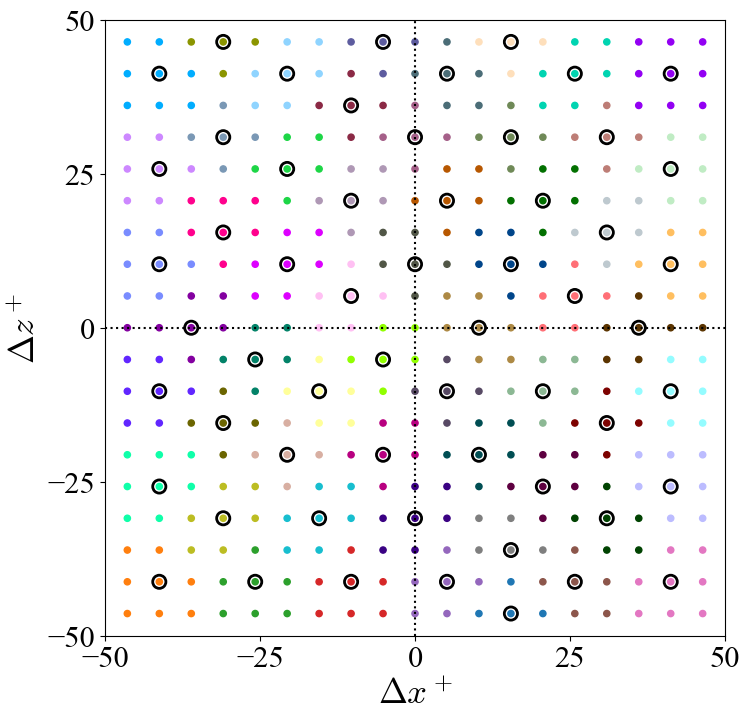

In [ ]:
fig = plt.figure(figsize=(8, 8))
# fig = plt.figure()
color_list = sns.color_palette(palette=cc.glasbey_category10,n_colors=n_clusters_)

# Create scatter plots for all points
plt.axvline(x=0, color='black', linestyle=':')
plt.axhline(y=0, color='black', linestyle=':')
plt.scatter(x_flatten, z_flatten, s=20, marker='o', c=[color_list[i] for i in labels])
plt.scatter(x_flatten[cluster_centers_indices],z_flatten[cluster_centers_indices],marker='o', s=90, linewidths=2, color='black',facecolors='none')

plt.ylim([-50,50])
plt.yticks([-50,-25,0,25,50])
plt.xlim([-50,50])
plt.xticks([-50,-25,0,25,50])
plt.xlabel(r'$\Delta x^+$', fontsize=25)
plt.ylabel(r'$\Delta z^+$', fontsize=25)
plt.tick_params(axis='both', labelsize=22)
# plt.savefig("PV_clusters.png",format='png',bbox_inches='tight')
# plt.savefig("PV_clusters.pdf",format='pdf',bbox_inches='tight')
plt.show()

# Average Model Training and Attribution

## Sensors

In [ ]:
# Define all sensor configurations for testing purposes
CAAF_sensors = np.array([182,187,129,139,106,243,231,204,93,260,283,267,226,103,134,300,218,294,63,197]) # 20 CAAF best so far
# sensors = np.array([182,160,139,150,214,218,173,143,197,146,204,134,283,226,288,221,311,100,231,36]) # 20 CAAF sensors with LSTM model (TEST)
TCN_CAAF_sensors = np.array([182,139,160,214,173,197,218,156,150,117,143,231,204,187,283,134,300,221,271,106]) # 20 CAAF sensors with TCN model
uniform10_sensors = np.array([0,   9,  18, 114, 123, 132, 228, 237, 246, 351]) # 10 uniform
uniform5_sensors = np.array([185,275,85,175,180])  # 5 evenly spaced
bayes_sensors = np.array([187, 72, 183, 216, 263, 139, 208, 318, 135, 181]) # 10 New Bayes OED
POD10_sensors = np.array([359, 324, 16, 230, 130, 76, 245, 6, 294, 141]) # 10 POD
POD5_sensors = np.array([355, 326, 71, 60, 199]) # 5 POD

# Initialize dicts for saving performance stats
test_errors_TCN = {}
test_corrs_TCN = {}

## MLP

Starting run 0
Random State = 40
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=5, out_features=50, bias=True)
  (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=50, out_features=50, bias=True)
  (5): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): LeakyReLU(negative_slope=0.01)
  (7): Linear(in_features=50, out_features=50, bias=True)
  (8): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): Linear(in_features=50, out_features=1, bias=True)
)
Model parameters: 5,751
Train Epoch: 1/150  Train Loss: 5.2478e-02, Test Loss: 1.1769e-02, Corr: 2.0183e-01, Loss Rate = -1.00e+00, Learning Rate = 3.00e-05
Train Epoch: 11/150  Train Loss: 6.3784e-03, Test Loss: 4.9852e-03, Corr: 4.0928e-01, Loss Rate = 1.09e-02, Learning Rate = 3.00e-05
Train Epoch: 21/1

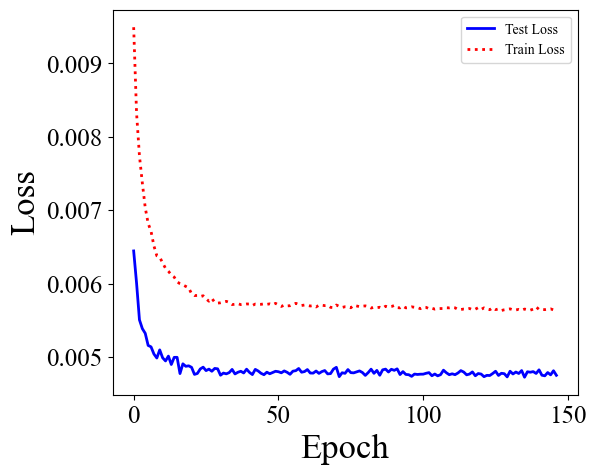

L2 errors = [[0.90479306]]
L2 errors = [[0.90479306]]
Average L2 error = 0.9047930606879644


In [ ]:
# SET Testing Sensors HERE
random_state_list = [40,19,179, 58,27]
n_iter = 1
n_sensors = 5
test_split = 0.1
# sensors = np.array([182,187,129,139,106,243,231,204,93,260,283,267,226,103,134,300,218,294,63,197]) # 20 CAAF best so far
# sensors = np.array([182,139,143,221,187,129,218,160,106,156,103,93,243,89,204,150,214,283,300,226]) # 20 CAAF with best model
# sensors = np.array([200,217,127,164,185,124,169,161,138,243,222,84,121,117,227,148,264,282,178,74]) # 74 cluster centers
# sensors = np.array([0,   9,  18, 114, 123, 132, 228, 237, 246, 351]) # 10 uniform
# sensors = np.array([187, 72, 183, 216, 263, 139, 208, 318, 135, 181]) # 10 Bayes OED
# sensors = np.array([359, 324, 16, 230, 130, 76, 245, 6, 294, 141]) # 10 POD
sensors = TCN_CAAF_sensors[:n_sensors]
# sensors = sensors[:n_sensors]

# sensors = np.random.choice(cluster_centers_indices, size=n_sensors, replace=False)
# sensors = cluster_centers_indices
# sensors = np.arange(n_probe)

mode = 'test'
# mode = 'attr'

use_GPU = True
#-------------------------------------------------------------------------------
best_model = None
best_error = 10.0
errors = np.zeros([n_iter,1])
weights_mean_all = np.zeros([n_iter,len(sensors)])
for iter in range(n_iter):
  print('Starting run', iter)
  # random_state = np.random.randint(0, 201)
  random_state = 40
  print('Random State =',random_state)
  X_train, X_test, y_train, y_test = train_test_split(
      P_scaled_train[:,sensors],
      V_scaled_train,
      test_size=test_split,
      shuffle=False,
      random_state=random_state
  )

  # make datasets and dataloaders
  train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
  test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

  # set random seed
  torch.manual_seed(random_state)
  train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
  test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=True)

  if use_GPU:
    torch.cuda.manual_seed(random_state)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.cuda.empty_cache()

  # Best model for 58 cluster centers
  if len(sensors) > 30:
    layer_size = 128
    model = nn.Sequential(
          nn.Flatten(),
          nn.Linear(len(sensors), layer_size,bias=True),
          nn.BatchNorm1d(layer_size),
          nn.LeakyReLU(),
          nn.Linear(layer_size, layer_size,bias=True),
          nn.BatchNorm1d(layer_size),
          nn.LeakyReLU(),
          # nn.Linear(layer_size, layer_size,bias=True),
          # nn.BatchNorm1d(layer_size),
          # nn.LeakyReLU(),
          nn.Linear(layer_size, 1,bias=True),
    )
  else:
    layer_size = 50
    model = nn.Sequential(
          nn.Flatten(),
          nn.Linear(len(sensors), layer_size,bias=True),
          nn.BatchNorm1d(layer_size),
          nn.LeakyReLU(),
          nn.Linear(layer_size, layer_size,bias=True),
          nn.BatchNorm1d(layer_size),
          nn.LeakyReLU(),
          nn.Linear(layer_size, layer_size,bias=True),
          nn.BatchNorm1d(layer_size),
          nn.LeakyReLU(),
          nn.Linear(layer_size, 1,bias=True),
    )

  model = model.to(torch.double)
  print(model)

  if use_GPU:
    model = model.to(device)

  print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

  optimizer = torch.optim.Adam(model.parameters(), lr=0.00003, weight_decay=1e-2)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, min_lr=1e-7, eps=1e-6, patience=2) # smaller eps more sensitive
  loss_fn = nn.MSELoss()
  # n_epochs = 20
  threshold = 1e-3   # early stopping threshold for test loss
  n_epochs_min = 40
  n_epochs_max = 150
  min_loss = 10.0
  print_interval = 10
  early_stop_patience = 20
  early_stop_counter = 0

  # store metrics
  training_loss_history = np.zeros([n_epochs_max, 1])
  validation_loss_history = np.zeros([n_epochs_max, 1])
  corr_history = np.zeros(n_epochs_max)

  for epoch in range(n_epochs_max):
      model.train()
      for batch_idx, (data, target) in enumerate(train_loader):
          if use_GPU:
            data, target = data.to(device), target.to(device)
          target = target.unsqueeze(1)
          # Erase accumulated gradients
          optimizer.zero_grad()

          # Forward pass
          # data = torch.squeeze(data)
          output = model(data)

          # Calculate loss
          loss = loss_fn(output, target)

          # Backward pass
          loss.backward()

          # Weight update
          optimizer.step()

          training_loss_history[epoch] += nn.MSELoss()(output, target).item()

      # Track loss each epoch
      training_loss_history[epoch] /= len(train_loader)
      if epoch % print_interval == 0:
        print(f'Train Epoch: %d/%i  Train Loss: %1.4e' % (epoch + 1, n_epochs_max, training_loss_history[epoch,0]),end='')


      # Turning off automatic differentiation
      with torch.no_grad():
          model.eval()
          for data, target in test_loader:
              if use_GPU:
                data, target = data.to(device), target.to(device)
              target = target.unsqueeze(1)
              output = model(data)
              validation_loss_history[epoch] += nn.MSELoss()(output, target).item()  # Sum up batch loss

              # compute correlation
              corr_epoch = np.corrcoef(output.cpu().detach().numpy().reshape((-1)), target.cpu().detach().numpy().reshape((-1)))[0,1]
              corr_history[epoch] += corr_epoch

          validation_loss_history[epoch] /= len(test_loader)
          corr_history[epoch] /= len(test_loader)
          if epoch % print_interval == 0:
            print(f', Test Loss: %1.4e' % validation_loss_history[epoch,0],end='')
            print(f', Corr: %1.4e' % corr_history[epoch],end='')

      loss_rate = (validation_loss_history[epoch-1]-validation_loss_history[epoch])/validation_loss_history[epoch]
      # loss_rate = (training_loss_history[epoch-1]-training_loss_history[epoch])/training_loss_history[epoch]
      if epoch % print_interval == 0:
        print(f', Loss Rate = %1.2e' % loss_rate[0],end='')
      # if epoch > n_epochs_min and loss_rate < threshold and loss_rate > 0: #loss_rate > 0 and
      #   break
      # if loss_rate < 0: early_stop_counter += 1
      # if epoch > n_epochs_min and ((early_stop_counter > early_stop_patience) or (loss_rate < threshold and loss_rate > 0)): #stop if loss_rate > 0 and < threshold
      #   break

      scheduler.step(validation_loss_history[epoch,0]) # adjust learning rate
      if epoch % print_interval == 0:
        print(f', Learning Rate = %1.2e' % optimizer.param_groups[0]['lr'])

  plt.rcParams['figure.figsize'] = [6, 5] # change figure size
  plt.plot(validation_loss_history[2:epoch], color='b',linewidth=2, label='Test Loss')
  plt.plot(training_loss_history[2:epoch],':',color='r',linewidth=2, label='Train Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

  # if validation_loss_history[epoch] < best_error:
  #   best_error = validation_loss_history[epoch]
  #   best_model = model

  if mode == 'test':
    with torch.no_grad():
    # input = P_val_input.unsqueeze(1)
      if use_GPU:
        X_test_temp = torch.tensor(X_test).to(device)
      else:
        X_test_temp = torch.tensor(X_test)
      test_output = model(X_test_temp).cpu().detach().numpy()

    if normalization == "01":
      test_output = unnormalize_01(test_output, V_min, V_max)
      y_test_unscaled = unnormalize_01(y_test, V_min, V_max)
    elif normalization == "m11":
      test_output = unnormalize_m1_1(test_output, V_mean, V_range)
      y_test_unscaled = unnormalize_m1_1(y_test, V_mean, V_range)
    elif normalization == "u_tau":
      test_output = unnormalize_utau(test_output, V_mean, utau, scale=1.0, square=False)
      y_test_unscaled = unnormalize_utau(y_test, V_mean, utau, scale=1.0, square=False)
    elif normalization == "u_tau_01":
      test_output = unnormalize_utau_01(test_output, V_mean, V_min, V_max, utau, scale=1.0, square=False)
      y_test_unscaled = unnormalize_utau_01(y_test, V_mean, V_min, V_max, utau, scale=1.0, square=False)
    elif normalization == "standard":
      test_output = scaler.inverse_transform(test_output.reshape(-1, 1)).reshape(-1)
      y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

    # compute L2 error

    errors[iter,0] = np.linalg.norm(test_output.reshape((-1)) - y_test_unscaled,2)/np.linalg.norm(y_test_unscaled - np.mean(y_test_unscaled),2) # L2 error norm
    if errors[iter,0] < best_error:
      best_error = errors[iter,0]
      best_model = model
    print('L2 errors =', errors)
  else:
    # Find most important sensors
    ig = captum.attr.IntegratedGradients(model)
    test_shap = torch.tensor(P_scaled_train[:,sensors])
    if use_GPU:
      test_shap = test_shap.to(device)
    test_shap.requires_grad_()
    attr = ig.attribute(test_shap,target=0,n_steps=50)
    attr = attr.cpu().detach().numpy()
    weights_mean_all[iter,:] = np.mean(abs(attr),axis=0) # average over time samples (1st axis)

if mode == 'test':
  print('L2 errors =', errors)
  print('Average L2 error =', np.mean(errors))
else:
  weights_mean = np.mean(weights_mean_all,axis=0) # average over iterations
  sensor_temp = np.flip(np.argsort(weights_mean))
  attr_sensors = sensors[sensor_temp[:n_sensors]] # Indices of the attribution sensor locations
  sensors_str = ','.join(map(str, attr_sensors)) #print "sensors" array as string and add commas
  print(str(n_sensors)+" attribution sensors:",sensors_str)

## TCN

Generating sequences of length 10...
Starting run 0
Random State = 40
Train Epoch: 1/150  Train Loss: 4.3158e-03, Test Loss: 3.4171e-03, Corr: 7.4755e-01, Loss Rate = -1.00e+00, Learning Rate = 1.00e-04
Train Epoch: 11/150  Train Loss: 1.6056e-03, Test Loss: 1.5914e-03, Corr: 8.9104e-01, Loss Rate = 7.94e-03, Learning Rate = 1.00e-04
Train Epoch: 21/150  Train Loss: 1.1594e-03, Test Loss: 1.1741e-03, Corr: 9.1599e-01, Loss Rate = 3.03e-02, Learning Rate = 1.00e-04
Train Epoch: 31/150  Train Loss: 9.3720e-04, Test Loss: 1.0168e-03, Corr: 9.2975e-01, Loss Rate = 8.99e-02, Learning Rate = 1.00e-04
Train Epoch: 41/150  Train Loss: 7.4126e-04, Test Loss: 9.0216e-04, Corr: 9.3658e-01, Loss Rate = 1.57e-02, Learning Rate = 2.50e-05
Train Epoch: 51/150  Train Loss: 7.0485e-04, Test Loss: 8.4091e-04, Corr: 9.4270e-01, Loss Rate = 9.89e-03, Learning Rate = 1.25e-05
Train Epoch: 61/150  Train Loss: 6.6626e-04, Test Loss: 8.1324e-04, Corr: 9.4203e-01, Loss Rate = 6.19e-03, Learning Rate = 6.25e-06

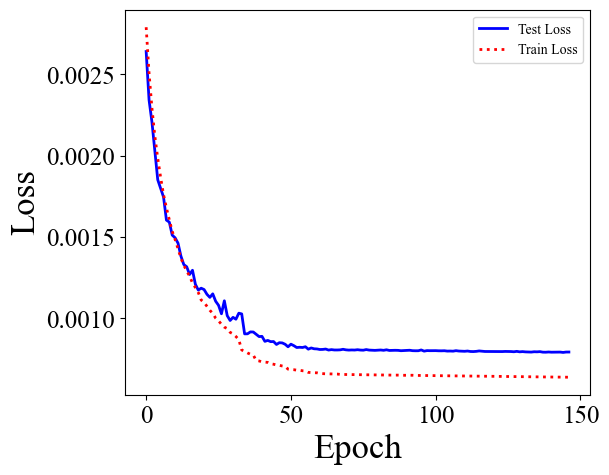

L2 errors = [[0.32198494]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]]
Correlation = [[0.94679005]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]]
Starting run 1
Random State = 19
Train Epoch: 1/150  Train Loss: 4.3599e-03, Test Loss: 3.4866e-03, Corr: 7.4679e-01, Loss Rate = -1.00e+00, Learning Rate = 1.00e-04
Train Epoch: 11/150  Train Loss: 1.6052e-03, Test Loss: 1.8720e-03, Corr: 8.8153e-01, Loss Rate = -3.66e-03, Learning Rate = 1.00e-04
Train Epoch: 21/150  Train Loss: 1.1307e-03, Test Loss: 1.3046e-03, Corr: 9.1399e-01, Loss Rate = 6.94e-03, Learning Rate = 1.00e-04
Train Epoch: 31/150  Train Loss: 8.8820e-04, Test Loss: 1.0575e-03, Corr: 9.2926e-01, Loss Rate = 4.96e-02, Learning Rate = 1.00e-04
Train Epoch: 41/150  Train Loss: 7.4884e-04, Test Loss: 9.1100e-04, Corr: 9.3931e-01, Loss Rate = 4.00e-02, Learning Rate = 1.00e-04
Train Epoch: 51/150  Train Loss: 6.4612e-04, Test Loss: 8.5317e-04, Corr: 9.4564e-01, Loss Rate = -4.77e-03, Learning Rate = 5.00e-05

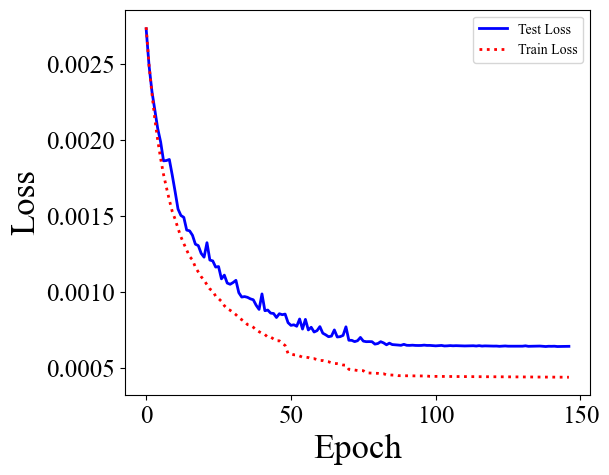

L2 errors = [[0.32198494]
 [0.28355405]
 [0.        ]
 [0.        ]
 [0.        ]]
Correlation = [[0.94679005]
 [0.95897263]
 [0.        ]
 [0.        ]
 [0.        ]]
Starting run 2
Random State = 179
Train Epoch: 1/150  Train Loss: 4.4422e-03, Test Loss: 3.4581e-03, Corr: 7.2563e-01, Loss Rate = -1.00e+00, Learning Rate = 1.00e-04
Train Epoch: 11/150  Train Loss: 1.6734e-03, Test Loss: 1.7886e-03, Corr: 8.7139e-01, Loss Rate = 3.78e-03, Learning Rate = 1.00e-04
Train Epoch: 21/150  Train Loss: 1.2004e-03, Test Loss: 1.3037e-03, Corr: 9.0471e-01, Loss Rate = 3.04e-02, Learning Rate = 1.00e-04
Train Epoch: 31/150  Train Loss: 9.4336e-04, Test Loss: 1.1591e-03, Corr: 9.2287e-01, Loss Rate = -3.37e-02, Learning Rate = 1.00e-04
Train Epoch: 41/150  Train Loss: 7.5905e-04, Test Loss: 9.3866e-04, Corr: 9.3226e-01, Loss Rate = 7.43e-02, Learning Rate = 2.50e-05
Train Epoch: 51/150  Train Loss: 6.9339e-04, Test Loss: 8.8836e-04, Corr: 9.3715e-01, Loss Rate = -5.81e-03, Learning Rate = 2.50e-0

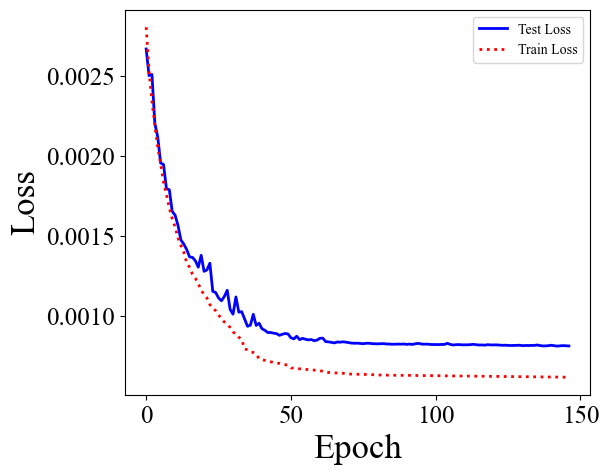

L2 errors = [[0.32198494]
 [0.28355405]
 [0.33300881]
 [0.        ]
 [0.        ]]
Correlation = [[0.94679005]
 [0.95897263]
 [0.94306222]
 [0.        ]
 [0.        ]]
Starting run 3
Random State = 58
Train Epoch: 1/150  Train Loss: 4.2960e-03, Test Loss: 3.6131e-03, Corr: 7.3808e-01, Loss Rate = -1.00e+00, Learning Rate = 1.00e-04
Train Epoch: 11/150  Train Loss: 1.6005e-03, Test Loss: 1.6686e-03, Corr: 8.7735e-01, Loss Rate = 6.79e-02, Learning Rate = 1.00e-04
Train Epoch: 21/150  Train Loss: 1.1313e-03, Test Loss: 1.2743e-03, Corr: 9.1461e-01, Loss Rate = 4.22e-02, Learning Rate = 1.00e-04
Train Epoch: 31/150  Train Loss: 8.9878e-04, Test Loss: 1.0728e-03, Corr: 9.2748e-01, Loss Rate = 4.12e-03, Learning Rate = 1.00e-04
Train Epoch: 41/150  Train Loss: 7.5080e-04, Test Loss: 8.9184e-04, Corr: 9.3832e-01, Loss Rate = 4.39e-02, Learning Rate = 1.00e-04
Train Epoch: 51/150  Train Loss: 6.5206e-04, Test Loss: 8.2713e-04, Corr: 9.4439e-01, Loss Rate = 5.65e-02, Learning Rate = 1.00e-04
T

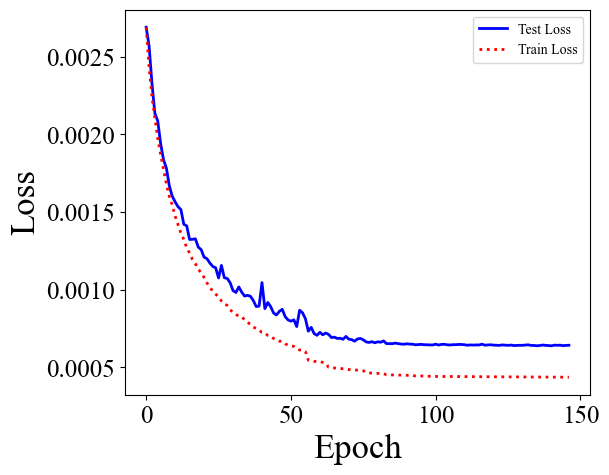

L2 errors = [[0.32198494]
 [0.28355405]
 [0.33300881]
 [0.28485516]
 [0.        ]]
Correlation = [[0.94679005]
 [0.95897263]
 [0.94306222]
 [0.95868122]
 [0.        ]]
Starting run 4
Random State = 27
Train Epoch: 1/150  Train Loss: 4.4114e-03, Test Loss: 3.3681e-03, Corr: 7.4064e-01, Loss Rate = -1.00e+00, Learning Rate = 1.00e-04
Train Epoch: 11/150  Train Loss: 1.6226e-03, Test Loss: 1.7099e-03, Corr: 8.7769e-01, Loss Rate = 8.15e-02, Learning Rate = 1.00e-04
Train Epoch: 21/150  Train Loss: 1.1273e-03, Test Loss: 1.3251e-03, Corr: 9.0814e-01, Loss Rate = -2.31e-02, Learning Rate = 1.00e-04
Train Epoch: 31/150  Train Loss: 8.8416e-04, Test Loss: 1.0010e-03, Corr: 9.3110e-01, Loss Rate = 1.39e-01, Learning Rate = 1.00e-04
Train Epoch: 41/150  Train Loss: 7.2672e-04, Test Loss: 8.5385e-04, Corr: 9.4045e-01, Loss Rate = 1.15e-01, Learning Rate = 1.00e-04
Train Epoch: 51/150  Train Loss: 6.1992e-04, Test Loss: 7.7234e-04, Corr: 9.4509e-01, Loss Rate = 4.29e-02, Learning Rate = 1.00e-04


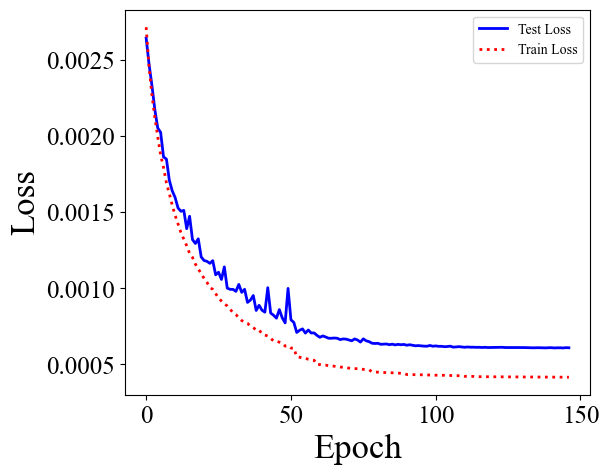

L2 errors = [[0.32198494]
 [0.28355405]
 [0.33300881]
 [0.28485516]
 [0.2861295 ]]
Correlation = [[0.94679005]
 [0.95897263]
 [0.94306222]
 [0.95868122]
 [0.95826228]]
L2 errors = [[0.32198494]
 [0.28355405]
 [0.33300881]
 [0.28485516]
 [0.2861295 ]]
Average L2 error = 0.3019064912938174


In [ ]:
n_iter = 5
n_sensors = 5
test_split = 0.1
seq_length = 10  # define sequence length
random_state_list = [40,19,179, 58,27]

# sensors = TCN_CAAF_sensors[:n_sensors]  # "TCN_CAAF"
# sensors = bayes_sensors[:n_sensors]   # "Bayes"
# sensors = uniform5_sensors[:n_sensors]    # "uniform"
# sensors = POD5_sensors[:n_sensors]    # "POD"
# sensors = CAAF_sensors[:n_sensors]    # "MLP_CAAF"
sensors = cluster_centers_indices   # "cluster_centers"

sensor_name = "cluster_centers"
save_to_dict = True

mode = 'test'
# mode = 'attr'

use_GPU = True

# Helper function to create sliding window sequences
def create_sequences(data_x, data_y, seq_len):
    xs, ys = [], []
    # Slide a window of size seq_len across the data
    for i in range(len(data_x) - seq_len + 1):
        xs.append(data_x[i:(i + seq_len)])
        # The target is the velocity at the final time step of the sequence
        ys.append(data_y[i + seq_len - 1])
    return np.array(xs), np.array(ys)

# TCN expects inputs to be (batch_size, channels, seq_length)
class TCNModel(nn.Module):
    def __init__(self, input_dim, seq_length=10, hidden_dim=64, output_dim=1):
        super(TCNModel, self).__init__()

        # 1D Convolutions act as the TCN filters sliding across your time window
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.flatten = nn.Flatten()
        # After flattening, the dense layer sees every feature at every time step simultaneously (like an MLP)
        self.fc = nn.Linear(hidden_dim * seq_length, output_dim)

    def forward(self, x):
        # Incoming x is shape: (batch_size, seq_length, input_dim)
        # PyTorch Conv1d requires shape: (batch_size, channels, seq_length)
        x = x.permute(0, 2, 1)

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))

        x = self.flatten(x)
        out = self.fc(x)
        return out
# ---------------------------------------------------

best_model = None
best_error = 10.0
errors = np.zeros([n_iter,1])
test_corrs = np.zeros([n_iter,1])
weights_mean_all = np.zeros([n_iter,len(sensors)])

# Pre-process the entire dataset into sequences before the loop to save time
print(f"Generating sequences of length {seq_length}...")
X_seq_full, y_seq_full = create_sequences(P_scaled_train[:, sensors], V_scaled_train, seq_length)

for iter in range(n_iter):
  print('Starting run', iter)
  # random_state = np.random.randint(0, 201)
  random_state = random_state_list[iter]
  # random_state = 40
  print('Random State =', random_state)

  # Split the sequential data
  X_train, X_test, y_train, y_test = train_test_split(
      X_seq_full,
      y_seq_full,
      test_size=test_split,
      shuffle=True,
      random_state=random_state
  )

  # make datasets and dataloaders
  train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.double), torch.tensor(y_train, dtype=torch.double))
  test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.double), torch.tensor(y_test, dtype=torch.double))

  # set random seed
  torch.manual_seed(random_state)
  train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
  test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

  if use_GPU:
    torch.cuda.manual_seed(random_state)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.cuda.empty_cache()

  # TCN init
  model = TCNModel(input_dim=len(sensors), seq_length=seq_length, hidden_dim=64)
  model = model.to(torch.double)

  if use_GPU:
    model = model.to(device)

  optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, min_lr=1e-7, eps=1e-6, patience=2)
  loss_fn = nn.MSELoss()

  n_epochs_max = 150
  print_interval = 10

  # store metrics
  training_loss_history = np.zeros([n_epochs_max, 1])
  validation_loss_history = np.zeros([n_epochs_max, 1])
  corr_history = np.zeros(n_epochs_max)

  for epoch in range(n_epochs_max):
      model.train()
      for batch_idx, (data, target) in enumerate(train_loader):
          if use_GPU:
            data, target = data.to(device), target.to(device)
          target = target.unsqueeze(1)

          optimizer.zero_grad()
          output = model(data)
          loss = loss_fn(output, target)
          loss.backward()
          optimizer.step()

          training_loss_history[epoch] += loss.item()

      training_loss_history[epoch] /= len(train_loader)
      if epoch % print_interval == 0:
        print(f'Train Epoch: %d/%i  Train Loss: %1.4e' % (epoch + 1, n_epochs_max, training_loss_history[epoch,0]),end='')

      with torch.no_grad():
          model.eval()
          for data, target in test_loader:
              if use_GPU:
                data, target = data.to(device), target.to(device)
              target = target.unsqueeze(1)
              output = model(data)
              validation_loss_history[epoch] += loss_fn(output, target).item()

              corr_epoch = np.corrcoef(output.cpu().detach().numpy().reshape((-1)), target.cpu().detach().numpy().reshape((-1)))[0,1]
              corr_history[epoch] += corr_epoch

          validation_loss_history[epoch] /= len(test_loader)
          corr_history[epoch] /= len(test_loader)

          if epoch % print_interval == 0:
            print(f', Test Loss: %1.4e' % validation_loss_history[epoch,0],end='')
            print(f', Corr: %1.4e' % corr_history[epoch],end='')

      loss_rate = (validation_loss_history[epoch-1]-validation_loss_history[epoch])/validation_loss_history[epoch]
      if epoch % print_interval == 0:
        print(f', Loss Rate = %1.2e' % loss_rate[0],end='')

      scheduler.step(validation_loss_history[epoch,0])
      if epoch % print_interval == 0:
        print(f', Learning Rate = %1.2e' % optimizer.param_groups[0]['lr'])

  plt.rcParams['figure.figsize'] = [6, 5]
  plt.plot(validation_loss_history[2:epoch], color='b',linewidth=2, label='Test Loss')
  plt.plot(training_loss_history[2:epoch],':',color='r',linewidth=2, label='Train Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

  if mode == 'test':
    with torch.no_grad():
      if use_GPU:
        X_test_temp = torch.tensor(X_test).to(device)
      else:
        X_test_temp = torch.tensor(X_test)
      test_output = model(X_test_temp).cpu().detach().numpy()

    # compute L2 error
    if normalization == "01":
      test_output = unnormalize_01(test_output, V_min, V_max)
      y_test_unscaled = unnormalize_01(y_test, V_min, V_max)
    elif normalization == "m11":
      test_output = unnormalize_m1_1(test_output, V_mean, V_range)
      y_test_unscaled = unnormalize_m1_1(y_test, V_mean, V_range)
    elif normalization == "u_tau":
      test_output = unnormalize_utau(test_output, V_mean, utau, scale=1.0, square=False)
      y_test_unscaled = unnormalize_utau(y_test, V_mean, utau, scale=1.0, square=False)
    elif normalization == "u_tau_01":
      test_output = unnormalize_utau_01(test_output, V_mean, V_min, V_max, utau, scale=1.0, square=False)
      y_test_unscaled = unnormalize_utau_01(y_test, V_mean, V_min, V_max, utau, scale=1.0, square=False)
    elif normalization == "standard":
      test_output = scaler.inverse_transform(test_output.reshape(-1, 1)).reshape(-1)
      y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

    # compute L2 error
    errors[iter,0] = np.linalg.norm(test_output.reshape((-1)) - y_test_unscaled,2)/np.linalg.norm(y_test_unscaled - np.mean(y_test_unscaled),2) # L2 error norm
    # errors[iter,0] = np.linalg.norm(test_output.reshape((-1)) - y_test,2)/np.linalg.norm(y_test - np.mean(y_test),2)

    # compute correlation
    test_corrs[iter,0] = np.corrcoef(test_output.reshape((-1)), y_test_unscaled)[0,1]

    if save_to_dict:
      if sensor_name in test_errors_TCN:
        test_errors_TCN[sensor_name].append(errors[iter,0])
        test_corrs_TCN[sensor_name].append(test_corrs[iter,0])
      else:
        test_errors_TCN[sensor_name] = [errors[iter,0]]
        test_corrs_TCN[sensor_name] = [test_corrs[iter,0]]


    if errors[iter,0] < best_error:
      best_error = errors[iter,0]
      best_model = model
    print('L2 errors =', errors)
    print('Correlation =', test_corrs)
  else:
    # Attribution
    model.train()
    # Specifically put the BatchNorm layers in eval mode
    for module in model.modules():
        if isinstance(module, nn.BatchNorm1d):
            module.eval()

    ig = captum.attr.IntegratedGradients(model)

    # Use the full generated training sequence for attribution evaluation
    attr_loader = DataLoader(torch.tensor(X_train, dtype=torch.double), batch_size=128, shuffle=False)

    attributions_list = []

    for batch_x in attr_loader:
        if use_GPU:
            batch_x = batch_x.to(device)
        batch_x.requires_grad_()

        batch_attr = ig.attribute(batch_x, target=0, n_steps=50)
        attributions_list.append(batch_attr.cpu().detach().numpy())
    model.eval()
    attr = np.concatenate(attributions_list, axis=0)

    # attr is now shape (samples, seq_length, n_sensors).
    # Average across both the samples (axis 0) and the time steps (axis 1)
    weights_mean_all[iter,:] = np.mean(abs(attr), axis=(0, 1))

if mode == 'test':
  print('L2 errors =', errors)
  print('Average L2 error =', np.mean(errors))
else:
  weights_mean = np.mean(weights_mean_all,axis=0)
  sensor_temp = np.flip(np.argsort(weights_mean))
  attr_sensors = sensors[sensor_temp[:n_sensors]]
  sensors_str = ','.join(map(str, attr_sensors))
  print(str(n_sensors)+" attribution sensors:",sensors_str)

In [ ]:
# print(test_corrs_TCN)
# print(test_errors_TCN)

for key,_ in test_corrs_TCN.items():
    value_array_errors = np.array(test_errors_TCN[key])
    value_array_corrs = np.array(test_corrs_TCN[key])
    avg_errors = np.mean(value_array_errors)
    avg_corrs = np.mean(value_array_corrs)

    # Print it out, formatting it to 2 decimal places
    print(f"{key} Error average: {avg_errors:.3f} Corr average: {avg_corrs:.3f}")

TCN_CAAF Error average: 0.547 Corr average: 0.837
uniform Error average: 0.600 Corr average: 0.800
Bayes Error average: 0.592 Corr average: 0.806
POD Error average: 0.644 Corr average: 0.765
cluster_centers Error average: 0.302 Corr average: 0.953


## LSTM

Generating sequences of length 10...
Starting run 0
Random State = 19
Train Epoch: 1/150  Train Loss: 4.9268e-03, Test Loss: 4.2599e-03, Corr: 6.8207e-01, Loss Rate = -1.00e+00, Learning Rate = 1.00e-04
Train Epoch: 11/150  Train Loss: 2.9188e-03, Test Loss: 3.0124e-03, Corr: 7.8565e-01, Loss Rate = 4.35e-02, Learning Rate = 1.00e-04
Train Epoch: 21/150  Train Loss: 2.5901e-03, Test Loss: 2.7285e-03, Corr: 8.0347e-01, Loss Rate = 3.02e-03, Learning Rate = 1.00e-04
Train Epoch: 31/150  Train Loss: 2.3511e-03, Test Loss: 2.5125e-03, Corr: 8.2851e-01, Loss Rate = -1.73e-02, Learning Rate = 1.00e-04
Train Epoch: 41/150  Train Loss: 2.1815e-03, Test Loss: 2.2888e-03, Corr: 8.4040e-01, Loss Rate = 2.30e-02, Learning Rate = 5.00e-05
Train Epoch: 51/150  Train Loss: 2.1076e-03, Test Loss: 2.2403e-03, Corr: 8.4066e-01, Loss Rate = 1.43e-02, Learning Rate = 2.50e-05
Train Epoch: 61/150  Train Loss: 2.0591e-03, Test Loss: 2.1971e-03, Corr: 8.4780e-01, Loss Rate = 6.23e-03, Learning Rate = 1.25e-0

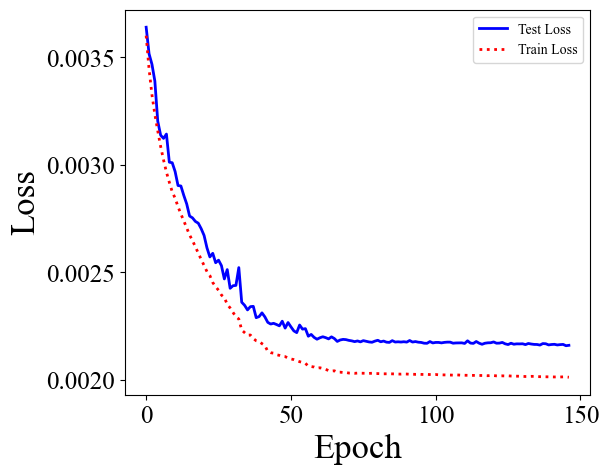

Starting run 1
Random State = 179
Train Epoch: 1/150  Train Loss: 5.1462e-03, Test Loss: 4.0505e-03, Corr: 6.6475e-01, Loss Rate = -1.00e+00, Learning Rate = 1.00e-04
Train Epoch: 11/150  Train Loss: 2.9162e-03, Test Loss: 2.9501e-03, Corr: 7.6884e-01, Loss Rate = 4.67e-03, Learning Rate = 1.00e-04
Train Epoch: 21/150  Train Loss: 2.5790e-03, Test Loss: 2.6438e-03, Corr: 7.9935e-01, Loss Rate = -4.08e-03, Learning Rate = 1.00e-04
Train Epoch: 31/150  Train Loss: 2.3820e-03, Test Loss: 2.4188e-03, Corr: 8.1810e-01, Loss Rate = 5.92e-04, Learning Rate = 1.00e-04
Train Epoch: 41/150  Train Loss: 2.2333e-03, Test Loss: 2.2777e-03, Corr: 8.2732e-01, Loss Rate = 1.17e-02, Learning Rate = 1.00e-04
Train Epoch: 51/150  Train Loss: 2.1138e-03, Test Loss: 2.1891e-03, Corr: 8.3529e-01, Loss Rate = -2.84e-02, Learning Rate = 1.00e-04
Train Epoch: 61/150  Train Loss: 2.0098e-03, Test Loss: 2.1477e-03, Corr: 8.3617e-01, Loss Rate = -3.46e-02, Learning Rate = 1.00e-04
Train Epoch: 71/150  Train Loss:

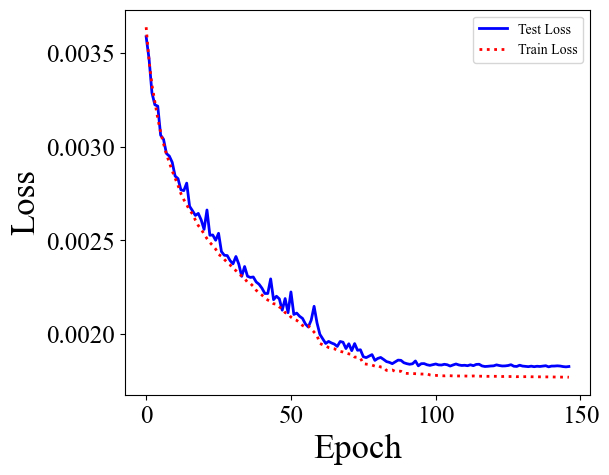

Starting run 2
Random State = 58
Train Epoch: 1/150  Train Loss: 4.9597e-03, Test Loss: 4.4901e-03, Corr: 6.5701e-01, Loss Rate = -1.00e+00, Learning Rate = 1.00e-04
Train Epoch: 11/150  Train Loss: 2.8956e-03, Test Loss: 3.0285e-03, Corr: 7.8214e-01, Loss Rate = 2.48e-02, Learning Rate = 1.00e-04
Train Epoch: 21/150  Train Loss: 2.5647e-03, Test Loss: 2.6273e-03, Corr: 8.0715e-01, Loss Rate = 6.96e-03, Learning Rate = 1.00e-04
Train Epoch: 31/150  Train Loss: 2.3322e-03, Test Loss: 2.4436e-03, Corr: 8.2602e-01, Loss Rate = -1.32e-03, Learning Rate = 1.00e-04
Train Epoch: 41/150  Train Loss: 2.1905e-03, Test Loss: 2.2738e-03, Corr: 8.3813e-01, Loss Rate = 7.34e-03, Learning Rate = 5.00e-05
Train Epoch: 51/150  Train Loss: 2.0906e-03, Test Loss: 2.2346e-03, Corr: 8.4363e-01, Loss Rate = -1.60e-02, Learning Rate = 2.50e-05
Train Epoch: 61/150  Train Loss: 2.0556e-03, Test Loss: 2.1676e-03, Corr: 8.4345e-01, Loss Rate = 3.98e-03, Learning Rate = 2.50e-05
Train Epoch: 71/150  Train Loss: 2

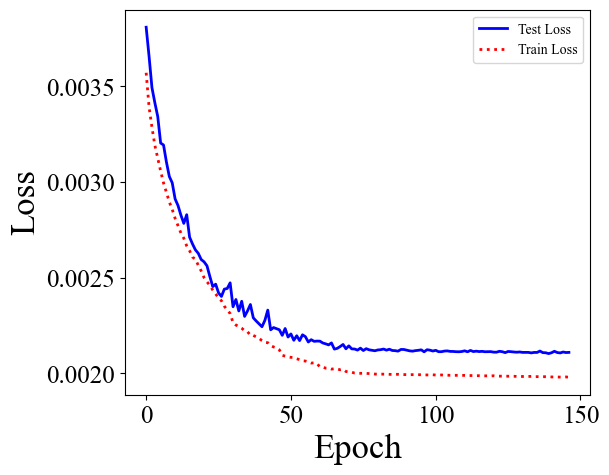

Starting run 3
Random State = 27
Train Epoch: 1/150  Train Loss: 5.3014e-03, Test Loss: 4.1711e-03, Corr: 6.7041e-01, Loss Rate = -1.00e+00, Learning Rate = 1.00e-04
Train Epoch: 11/150  Train Loss: 2.9553e-03, Test Loss: 3.0011e-03, Corr: 7.6968e-01, Loss Rate = 1.43e-03, Learning Rate = 1.00e-04
Train Epoch: 21/150  Train Loss: 2.6199e-03, Test Loss: 2.7000e-03, Corr: 7.9572e-01, Loss Rate = 1.52e-02, Learning Rate = 1.00e-04
Train Epoch: 31/150  Train Loss: 2.3843e-03, Test Loss: 2.5055e-03, Corr: 8.0624e-01, Loss Rate = 4.50e-02, Learning Rate = 1.00e-04
Train Epoch: 41/150  Train Loss: 2.2086e-03, Test Loss: 2.3313e-03, Corr: 8.2598e-01, Loss Rate = -8.67e-03, Learning Rate = 1.00e-04
Train Epoch: 51/150  Train Loss: 2.0822e-03, Test Loss: 2.2659e-03, Corr: 8.3131e-01, Loss Rate = 7.87e-03, Learning Rate = 2.50e-05
Train Epoch: 61/150  Train Loss: 2.0114e-03, Test Loss: 2.1736e-03, Corr: 8.3614e-01, Loss Rate = 1.19e-02, Learning Rate = 2.50e-05
Train Epoch: 71/150  Train Loss: 1.

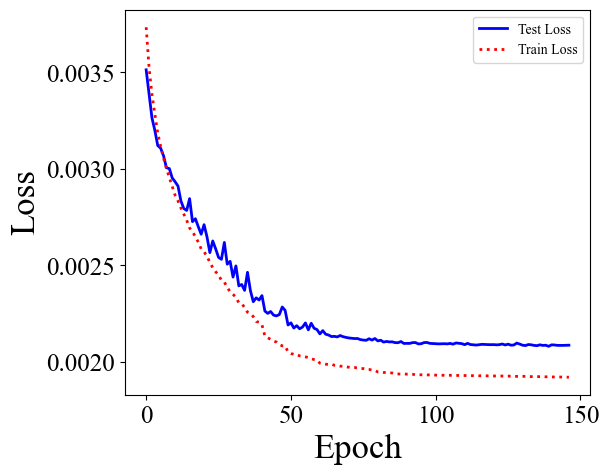

Starting run 4
Random State = 40
Train Epoch: 1/150  Train Loss: 5.0415e-03, Test Loss: 4.1268e-03, Corr: 6.8336e-01, Loss Rate = -1.00e+00, Learning Rate = 1.00e-04
Train Epoch: 11/150  Train Loss: 2.9395e-03, Test Loss: 2.8054e-03, Corr: 7.9543e-01, Loss Rate = 4.38e-02, Learning Rate = 1.00e-04
Train Epoch: 21/150  Train Loss: 2.5818e-03, Test Loss: 2.5084e-03, Corr: 8.1841e-01, Loss Rate = 8.11e-03, Learning Rate = 1.00e-04
Train Epoch: 31/150  Train Loss: 2.3674e-03, Test Loss: 2.3056e-03, Corr: 8.3138e-01, Loss Rate = 1.13e-02, Learning Rate = 1.00e-04
Train Epoch: 41/150  Train Loss: 2.2077e-03, Test Loss: 2.1529e-03, Corr: 8.4016e-01, Loss Rate = 1.69e-02, Learning Rate = 1.00e-04
Train Epoch: 51/150  Train Loss: 2.0548e-03, Test Loss: 2.0660e-03, Corr: 8.4799e-01, Loss Rate = -1.47e-02, Learning Rate = 5.00e-05
Train Epoch: 61/150  Train Loss: 1.9979e-03, Test Loss: 1.9763e-03, Corr: 8.5863e-01, Loss Rate = 4.83e-03, Learning Rate = 5.00e-05
Train Epoch: 71/150  Train Loss: 1.

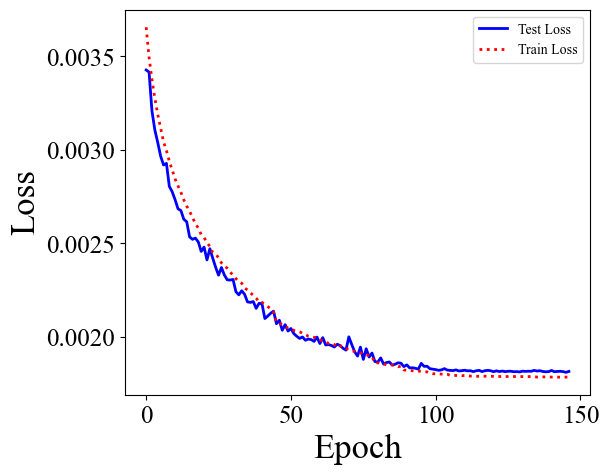

20 attribution sensors: 182,160,214,150,139,146,218,197,204,143,173,134,226,283,60,221,340,106,311,288


In [ ]:
n_iter = 5
n_sensors = 20
test_split = 0.1
seq_length = 10  # define sequence length
random_state_list = [19,179, 58,27,40]
# sensors = np.array([182,187,129,139,106,243,231,204,93,260,283,267,226,103,134,300,218,294,63,197]) # 20 CAAF best so far
# sensors = np.array([187, 72, 183, 216, 263, 139, 208, 318, 135, 181]) # 10 Bayes OED
# sensors = np.array([182,160,139,150,214,218,173,143,197,146,204,134,283,226,288,221,311,100,231,36]) # 20 CAAF sensors with LSTM model (TEST)
# sensors = sensors[:n_sensors]
sensors = cluster_centers_indices

# mode = 'test'
mode = 'attr'

use_GPU = True

# Helper function to create sliding window sequences
def create_sequences(data_x, data_y, seq_len):
    xs, ys = [], []
    # Slide a window of size seq_len across the data
    for i in range(len(data_x) - seq_len + 1):
        xs.append(data_x[i:(i + seq_len)])
        # The target is the velocity at the final time step of the sequence
        ys.append(data_y[i + seq_len - 1])
    return np.array(xs), np.array(ys)

# LSTM expects native 3D inputs now
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, output_dim=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x is expected to be (batch_size, seq_length, features)
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Extract the output of the final time step in the sequence
        out = self.fc(out)
        return out
# ---------------------------------------------------

best_model = None
best_error = 10.0
errors = np.zeros([n_iter,1])
weights_mean_all = np.zeros([n_iter,len(sensors)])

# Pre-process the entire dataset into sequences before the loop to save time
print(f"Generating sequences of length {seq_length}...")
X_seq_full, y_seq_full = create_sequences(P_scaled_train[:, sensors], V_scaled_train, seq_length)

for iter in range(n_iter):
  print('Starting run', iter)
  # random_state = np.random.randint(0, 201)
  random_state = random_state_list[iter]
  # random_state = 40
  print('Random State =', random_state)

  # Split the sequential data
  X_train, X_test, y_train, y_test = train_test_split(
      X_seq_full,
      y_seq_full,
      test_size=test_split,
      shuffle=True,
      random_state=random_state
  )

  # make datasets and dataloaders
  train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.double), torch.tensor(y_train, dtype=torch.double))
  test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.double), torch.tensor(y_test, dtype=torch.double))

  # set random seed
  torch.manual_seed(random_state)
  train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
  test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

  if use_GPU:
    torch.cuda.manual_seed(random_state)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.cuda.empty_cache()

  # if len(sensors) > 30:
  #   layer_size = 128
  # else:
  #   layer_size = 50

  model = LSTMModel(input_dim=len(sensors), hidden_dim=64, num_layers=2)
  model = model.to(torch.double)

  if use_GPU:
    model = model.to(device)

  optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, min_lr=1e-7, eps=1e-6, patience=2)
  loss_fn = nn.MSELoss()

  n_epochs_max = 150
  print_interval = 10

  # store metrics
  training_loss_history = np.zeros([n_epochs_max, 1])
  validation_loss_history = np.zeros([n_epochs_max, 1])
  corr_history = np.zeros(n_epochs_max)

  for epoch in range(n_epochs_max):
      model.train()
      for batch_idx, (data, target) in enumerate(train_loader):
          if use_GPU:
            data, target = data.to(device), target.to(device)
          target = target.unsqueeze(1)

          optimizer.zero_grad()
          output = model(data)
          loss = loss_fn(output, target)
          loss.backward()
          optimizer.step()

          training_loss_history[epoch] += loss.item()

      training_loss_history[epoch] /= len(train_loader)
      if epoch % print_interval == 0:
        print(f'Train Epoch: %d/%i  Train Loss: %1.4e' % (epoch + 1, n_epochs_max, training_loss_history[epoch,0]),end='')

      with torch.no_grad():
          model.eval()
          for data, target in test_loader:
              if use_GPU:
                data, target = data.to(device), target.to(device)
              target = target.unsqueeze(1)
              output = model(data)
              validation_loss_history[epoch] += loss_fn(output, target).item()

              corr_epoch = np.corrcoef(output.cpu().detach().numpy().reshape((-1)), target.cpu().detach().numpy().reshape((-1)))[0,1]
              corr_history[epoch] += corr_epoch

          validation_loss_history[epoch] /= len(test_loader)
          corr_history[epoch] /= len(test_loader)

          if epoch % print_interval == 0:
            print(f', Test Loss: %1.4e' % validation_loss_history[epoch,0],end='')
            print(f', Corr: %1.4e' % corr_history[epoch],end='')

      loss_rate = (validation_loss_history[epoch-1]-validation_loss_history[epoch])/validation_loss_history[epoch]
      if epoch % print_interval == 0:
        print(f', Loss Rate = %1.2e' % loss_rate[0],end='')

      scheduler.step(validation_loss_history[epoch,0])
      if epoch % print_interval == 0:
        print(f', Learning Rate = %1.2e' % optimizer.param_groups[0]['lr'])

  plt.rcParams['figure.figsize'] = [6, 5]
  plt.plot(validation_loss_history[2:epoch], color='b',linewidth=2, label='Test Loss')
  plt.plot(training_loss_history[2:epoch],':',color='r',linewidth=2, label='Train Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

  if mode == 'test':
    with torch.no_grad():
      if use_GPU:
        X_test_temp = torch.tensor(X_test).to(device)
      else:
        X_test_temp = torch.tensor(X_test)
      test_output = model(X_test_temp).cpu().detach().numpy()

    # compute L2 error
    errors[iter,0] = np.linalg.norm(test_output.reshape((-1)) - y_test,2)/np.linalg.norm(y_test - np.mean(y_test),2)

    if errors[iter,0] < best_error:
      best_error = errors[iter,0]
      best_model = model
    print('L2 errors =', errors)
  else:
    # Attribution
    model.train()
    # Specifically put the BatchNorm layers in eval mode
    for module in model.modules():
        if isinstance(module, nn.BatchNorm1d):
            module.eval()

    ig = captum.attr.IntegratedGradients(model)

    # Use the full generated training sequence for attribution evaluation
    attr_loader = DataLoader(torch.tensor(X_train, dtype=torch.double), batch_size=128, shuffle=False)

    attributions_list = []

    for batch_x in attr_loader:
        if use_GPU:
            batch_x = batch_x.to(device)
        batch_x.requires_grad_()

        batch_attr = ig.attribute(batch_x, target=0, n_steps=50)
        attributions_list.append(batch_attr.cpu().detach().numpy())
    model.eval()
    attr = np.concatenate(attributions_list, axis=0)

    # attr is now shape (samples, seq_length, n_sensors).
    # Average across both the samples (axis 0) and the time steps (axis 1)
    weights_mean_all[iter,:] = np.mean(abs(attr), axis=(0, 1))

if mode == 'test':
  print('L2 errors =', errors)
  print('Average L2 error =', np.mean(errors))
else:
  weights_mean = np.mean(weights_mean_all,axis=0)
  sensor_temp = np.flip(np.argsort(weights_mean))
  attr_sensors = sensors[sensor_temp[:n_sensors]]
  sensors_str = ','.join(map(str, attr_sensors))
  print(str(n_sensors)+" attribution sensors:",sensors_str)

# Testing and ploting

In [ ]:
## Data saving and exporting
with open('test_errors_TCN_5.pkl', 'wb') as f:
    pickle.dump(test_errors_TCN, f)
with open('test_corrs_TCN_5.pkl', 'wb') as f:
    pickle.dump(test_corrs_TCN, f)

## Loading dict
# with open('test_corrs_TCN_5.pkl', 'rb') as f:
#     test_corrs_TCN = pickle.load(f)
# with open('test_errors_TCN_5.pkl', 'rb') as f:
#     test_errors_TCN = pickle.load(f)

# df = pd.DataFrame(test_errors_TCN)
# df.to_csv('test_errors_TCN_5.csv', index=False)
# df = pd.DataFrame(test_corrs_TCN)
# df.to_csv('test_corrs_TCN_5.csv', index=False)

# torch.save(model,"Channel_PV_LSTM_CAAF_on_LSTM_seed40.pt")
# torch.save(model,"Channel_PV_MLP_CAAF_on_LSTM_seed40.pt")
# torch.save(model,"Channel_PV_5TCN_CAAF_on_TCN_seed27.pt")
# torch.save(model,"Channel_PV_5MLP_CAAF_on_TCN_seed40.pt")
# torch.save(model,"Channel_PV_5MLP_CAAF_on_MLP_seed40.pt")
# torch.save(model,"Channel_PV_5uniform_on_TCN_seed27.pt")
# torch.save(model,"Channel_PV_5Bayes_on_TCN_seed27.pt")
# torch.save(model,"Channel_PV_5POD_on_TCN_seed27.pt")
# torch.save(model,"Channel_PV_5TCN_CAAF_on_MLP_seed40.pt")
# torch.save(model,"test.pt")

In [ ]:
def evaluate_model(model,sensors,seq = False, normalization="m11",verbose = False):
  if not seq:
    X_test = P_eval[:,sensors]
    y_test = V_eval
  else:
    X_test, y_test = create_sequences(P_eval[:,sensors], V_eval, seq_length)

  with torch.no_grad():
    # input = P_val_input.unsqueeze(1)
    if use_GPU:
      X_test_temp = torch.tensor(X_test).to(device)
    else:
      X_test_temp = torch.tensor(X_test)
    test_output = model(X_test_temp).cpu().detach().numpy()

    if normalization == "01":
      test_output = unnormalize_01(test_output, V_min, V_max)
      y_test_unscaled = unnormalize_01(y_test, V_min, V_max)
    elif normalization == "m11":
      test_output = unnormalize_m1_1(test_output, V_mean, V_range)
      y_test_unscaled = unnormalize_m1_1(y_test, V_mean, V_range)
    elif normalization == "u_tau":
      test_output = unnormalize_utau(test_output, V_mean, utau, scale=1.0, square=False)
      y_test_unscaled = unnormalize_utau(y_test, V_mean, utau, scale=1.0, square=False)
    elif normalization == "u_tau_01":
      test_output = unnormalize_utau_01(test_output, V_mean, V_min, V_max, utau, scale=1.0, square=False)
      y_test_unscaled = unnormalize_utau_01(y_test, V_mean, V_min, V_max, utau, scale=1.0, square=False)
    elif normalization == "standard":
      test_output = scaler.inverse_transform(test_output.reshape(-1, 1)).reshape(-1)
      y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

  #compute L2 error using unscaled quantities
  error2 = np.linalg.norm(test_output.reshape((-1)) - y_test_unscaled,2)/np.linalg.norm(y_test_unscaled - np.mean(y_test_unscaled),2) # L2 error norm

  # compute correlation between test_output and y_test_unscaled
  test_corr = np.corrcoef(test_output.reshape((-1)), y_test_unscaled)[0,1]

  if verbose:
    print('L2 error =', error2)
    print('Correlation =', test_corr)

  return test_output/utau, y_test_unscaled/utau, error2, test_corr

def load_and_plot_model(filename, sensors, seq, color, label, verbose = True, plot_line='-'):
    """
    Loads a single model, evaluates it, and adds its prediction to the active plot.
    Returns the time_list and y_test_unscaled so you can plot the 'True' line afterwards.
    """
    # 1. Load the model
    model = torch.load(filename, weights_only=False).to(device).eval()
    if verbose:
      print(filename[:-3]+": ")

    # 2. Evaluate the model
    test_output, y_test_unscaled, error2, test_corr = evaluate_model(
        model, sensors, seq=seq, verbose=verbose
    )

    # 3. Calculate time list based on whether it is a sequence model
    if seq:
        time_list = np.arange(test_output.shape[0]) * dt_plus
    else:
        time_list = np.arange(test_output.shape[0]) * dt_plus - dt_plus * (seq_length - 1)

    # 4. Plot the predicted line
    plt.plot(time_list, test_output, linestyle=plot_line, color=color, label=label)

    return time_list, y_test_unscaled

Channel_PV_5uniform_on_TCN_seed27: 
L2 error = 0.5877883450205619
Correlation = 0.8154506936738853
Channel_PV_5TCN_CAAF_on_TCN_seed27: 
L2 error = 0.5508751893203532
Correlation = 0.835298478992669


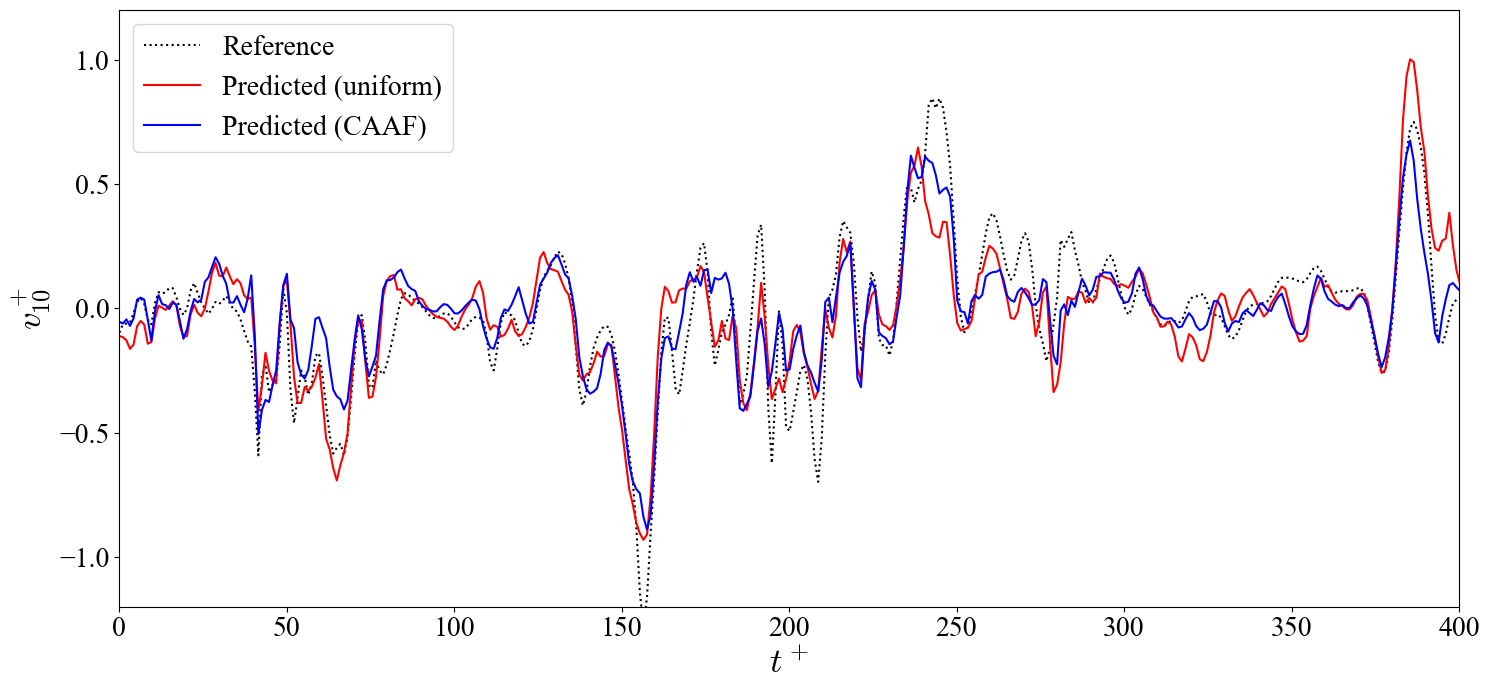

In [ ]:
# Plot and compare time series predictions
plt.rcParams['figure.figsize'] = [15, 7] # change figure size
plt.rc('axes', labelsize=25, titlesize=25 )
plt.rc('xtick',labelsize=18)
plt.rc('ytick',labelsize=18)
# CAAF_sensors = np.array([182,187,129,139,106,243,231,204,93,260,283,267,226,103,134,300,218,294,63,197]) # 20 CAAF best so far
# LSTM_CAAF_sensors = np.array([182,160,139,150,214,218,173,143,197,146,204,134,283,226,288,221,311,100,231,36]) # 20 LSTM CAAF sensors
# TCN_sensors = np.array([182,139,160,214,173,197,218,156,150,117,143,231,204,187,283,134,300,221,271,106]) # 20 TCN CAAF sensors
# bayes_sensors = np.array([187, 72, 183, 216, 263, 139, 208, 318, 135, 181]) # 10 Bayes OED
# POD_sensors = np.array([359, 324, 16, 230, 130, 76, 245, 6, 294, 141]) # 10 POD
# sensors_uniform = np.array([0,   9,  18, 114, 123, 132, 228, 237, 246, 351])  # evenly spaced
n_sensors = 5

# # MLP on TCN Model
# _, _ = load_and_plot_model(
#     filename="Channel_PV_5MLP_CAAF_on_TCN_seed40.pt", # update with your actual TCN filename
#     sensors=CAAF_sensors[:n_sensors],
#     seq=True,
#     color='c',
#     label='Predicted (MLP-TCN)',
# )

# # MLP Model
# _, _ = load_and_plot_model(
#     filename="Channel_PV_5TCN_CAAF_on_MLP_seed40.pt", # update with your actual TCN filename
#     sensors=TCN_CAAF_sensors[:n_sensors],
#     seq=False,
#     color='g',
#     label='Predicted (MLP-MLP)',
# )

# # MLP Model
# _, _ = load_and_plot_model(
#     filename="Channel_PV_5MLP_CAAF_on_MLP_seed40.pt", # update with your actual TCN filename
#     sensors=CAAF_sensors[:n_sensors],
#     seq=False,
#     color='g',
#     label='Predicted (MLP-MLP)',
# )

# # POD on TCN Model
# _, _ = load_and_plot_model(
#     filename="Channel_PV_5POD_on_TCN_seed27.pt", # update with your actual TCN filename
#     sensors=POD5_sensors[:n_sensors],
#     seq=True,
#     color='orange',
#     label='Predicted (POD)',
# )

# # Bayes on TCN Model
# _, _ = load_and_plot_model(
#     filename="Channel_PV_5Bayes_on_TCN_seed27.pt", # update with your actual TCN filename
#     sensors=bayes_sensors[:n_sensors],
#     seq=True,
#     color='green',
#     label='Predicted (Bayes)',
# )

# Uniform Model (grabbing the outputs to plot the 'True' line)
time_list_uniform, y_true_uniform = load_and_plot_model(
    filename="Channel_PV_5uniform_on_TCN_seed27.pt",
    sensors=uniform5_sensors[:n_sensors],
    seq=True,
    color='r',
    label='Predicted (uniform)',
)


# TCN Model
_, _ = load_and_plot_model(
    filename="Channel_PV_5TCN_CAAF_on_TCN_seed27.pt", # update with your actual TCN filename
    sensors=TCN_CAAF_sensors[:n_sensors],
    seq=True,
    color='b',
    label='Predicted (CAAF)',
)

# Plot the shared "True" reference line
plt.plot(time_list_uniform, y_true_uniform, ':', color='k', label='Reference')

plt.xlabel(r'$t^+$')
plt.ylabel(r'$v_{10}^+$')
plt.ylim([-1.2,1.2])
# plt.xlim([0,1000])
# plt.yticks([0.001,0.0015,0.002,0.0025,0.003])
plt.xlim([0,400])
plt.tick_params(axis='both', labelsize=20)
plt.tight_layout()

# plt.savefig("PV_Pred_Compare_CAAF_uniform_new.pdf",format='pdf')
# plt.savefig("PV_Pred_Compare_CAAF_uniform_new.eps",format='eps')
# error2_str = r'$\varepsilon =$ %1.3f' % error2
# corr_str = r'$corr(v_{\mathrm{true}},v_{\mathrm{pred}}) =$ %1.3f' % test_corr
# plt.annotate(error2_str,(20,50),xycoords='axes points',fontsize=30)
# plt.annotate(corr_str,(20,20),xycoords='axes points',fontsize=28)
plt.legend(loc='best',fontsize=20)
plt.show()

Dimensionless time lag: 0.0000


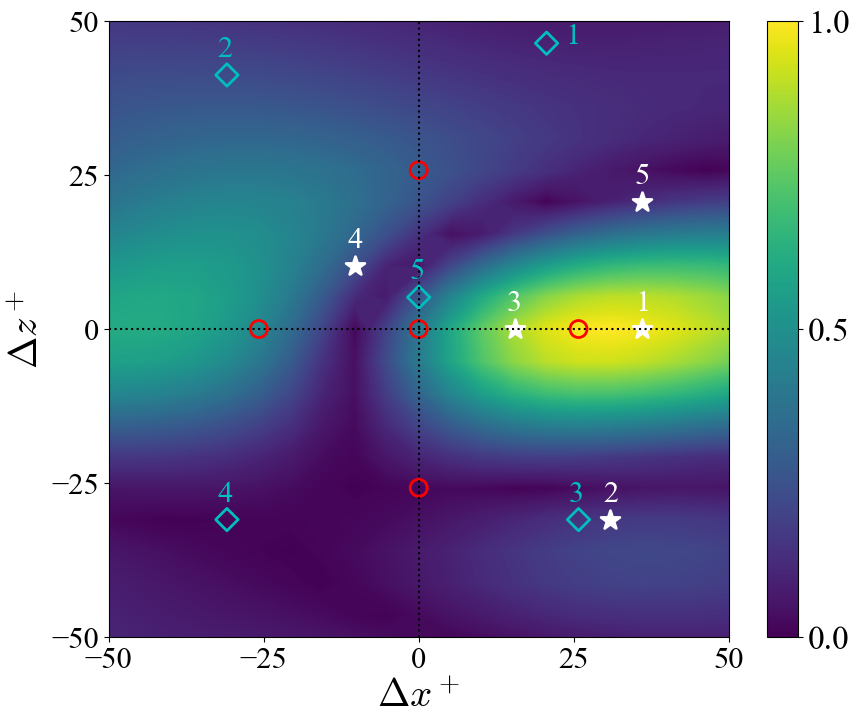

In [ ]:
# Plot sensor configurations
fig = plt.figure(figsize=(10, 8))
# Create scatter plots for all points
plt.axvline(x=0, color='black', linestyle=':')
plt.axhline(y=0, color='black', linestyle=':')

# Add X-corr
plot_corr = True
# data = scipy.io.loadmat('CrossCorr_mean.mat')
# CrossCorr_mean = data['CrossCorr_mean']
if plot_corr:
  plot_tlag = 0
  lag_idx_plot = max_tlag + plot_tlag
  x_plus_list = np.arange(-10,11)*dx
  Xgrid, Zgrid = np.meshgrid(x_plus_list, x_plus_list)
  levels = np.linspace(0, 1, 500)
  contour = plt.contourf(Xgrid, Zgrid, CrossCorr_mean[lag_idx_plot, :, :].T, levels=levels, linestyles='none',cmap='viridis')
  contour.set_edgecolor("face") # make sure there's no contours lines in AI
  print(f"Dimensionless time lag: {plot_tlag*dt_plus:.4f}")
  plt.colorbar(contour, ticks=[0, 0.5, 1])
  plt.clim(0, 1)  # Set color limits

# # Remove edge artifacts from contour polygons
# for c in contour.collections:
#     c.set_edgecolor("face")

for j in uniform5_sensors[:5]:
  plt.scatter(x_flatten[j], z_flatten[j], marker='o', s=150, facecolors='none', color='red', linewidth=2)

rank = 1
for j in POD5_sensors:
  # plt.scatter(x_flatten[j], z_flatten[j], marker='D', s=90, facecolors='none', color='yellow', linewidth=2)
  # annotation = plt.annotate(str(rank), (x_flatten[j]-1.2, z_flatten[j]+2), fontsize=22, color='yellow')
  plt.scatter(x_flatten[j], z_flatten[j], marker='D', s=130, facecolors='none', color='c', linewidth=2)
  if rank == 1:
    annotation = plt.annotate(str(rank), (x_flatten[j]+3, z_flatten[j]), fontsize=22, color='c')
  else:
    annotation = plt.annotate(str(rank), (x_flatten[j]-1.5, z_flatten[j]+3), fontsize=22, color='c')
  rank += 1

rank = 1
for j in bayes_sensors[:5]:
  plt.scatter(x_flatten[j], z_flatten[j], marker='*', s=200, color='white', linewidth=2)
  annotation = plt.annotate(str(rank), (x_flatten[j]-1.2, z_flatten[j]+3), fontsize=22, color='white')
  rank += 1

# rank = 1
# for i in TCN_CAAF_sensors[:5]:
#   plt.scatter(x_flatten[i], z_flatten[i], marker='x', s=150, color='white', linewidth=2)
#   annotation = plt.annotate(str(rank), (x_flatten[i]-1.2, z_flatten[i]+3), fontsize=22, color='white')
#   rank += 1

plt.ylim([-50,50])
plt.yticks([-50,-25,0,25,50])
plt.xlim([-50,50])
plt.xticks([-50,-25,0,25,50])
plt.xlabel('$\Delta x^+$')
plt.ylabel('$\Delta z^+$')
# plt.gca().set_aspect('equal', adjustable='datalim')
plt.tick_params(axis='both', labelsize=22)
# plt.savefig("PV_sensors_uniform_POD.png",format='png',dpi=600)
# plt.savefig("PV_sensors_uniform_POD.pdf",format='pdf',bbox_inches='tight')
# plt.savefig("PV_sensors_uniform_POD_Bayes.png",format='png',dpi=600)
# plt.savefig("PV_sensors_uniform_POD_Bayes.pdf",format='pdf',bbox_inches='tight')
plt.show()

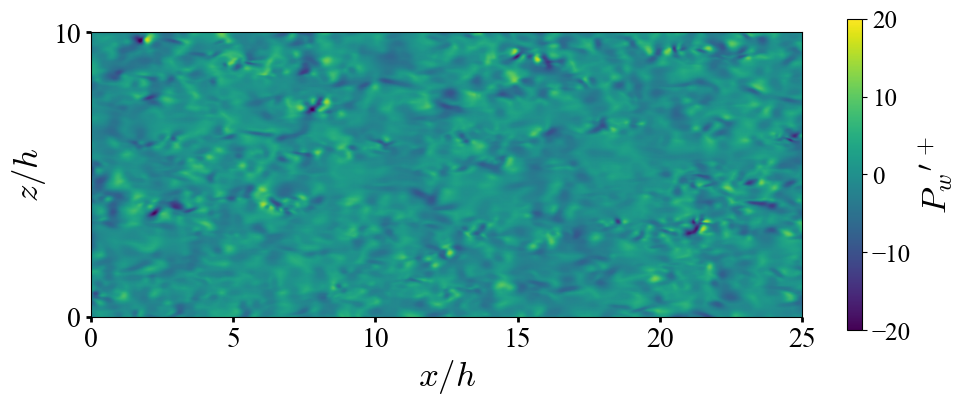

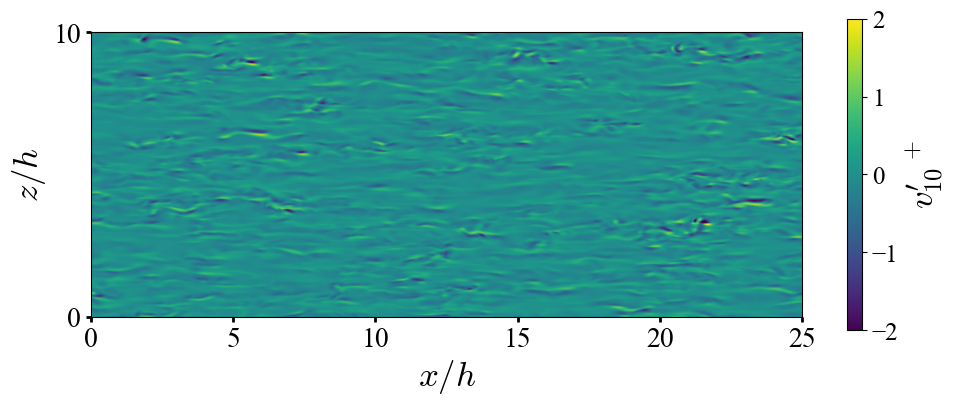

In [ ]:
# Plot instant fields P and V
# === Load data ===
V = scipy.io.loadmat("V_t10000.mat")["V"]
P_w = scipy.io.loadmat("P_w_t10000.mat")["P_w"]
x = scipy.io.loadmat("x_edge.mat")["x"].squeeze()
y = scipy.io.loadmat("y_edge.mat")["y"].squeeze()
z = scipy.io.loadmat("z_edge.mat")["z"].squeeze()

# === Constants ===
Retau = 186.0
utau = 0.057231058999996
mu = 3.076923076923077e-04

# === Plot P_w ===
P_w_prime = P_w - np.mean(P_w)

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_box_aspect(1/2.5)
ax.tick_params(labelsize=20, width=2)

# Note: Transpose P_w_prime for same orientation as MATLAB (using .T)
levels = np.linspace(-20, 20, 500)  # define range explicitly
c = ax.pcolormesh(x, z, (P_w_prime.T * 2) / (utau**2), cmap='viridis', rasterized=True, shading='gouraud')

c.set_clim(-20, 20) # clim is set by colorbar now
cb=plt.colorbar(c, ax=ax, ticks=np.arange(-20, 21, 10))
cb.set_label(r"${P_{w}}'^+$", fontsize=25) # colorbar title

ax.set_ylim([0, 10])
ax.set_xlim([0, 25])
ax.set_yticks(np.arange(0, 11, 10))
ax.set_xlabel(r"$x/h$", fontsize=25)
ax.set_ylabel(r"$z/h$", fontsize=25)

plt.tight_layout()
plt.savefig("P_w_instant.pdf",dpi=150, bbox_inches='tight')
plt.show()

# === Plot V at y+ = 10 ===
v = (V - np.mean(V)) / utau
v_min, v_max = np.min(v), np.max(v)

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_box_aspect(1/2.5)
ax.tick_params(labelsize=20, width=2)

levels = np.linspace(-2, 2, 500)  # define range explicitly
c = ax.pcolormesh(x, z, v.T, cmap='viridis', rasterized=True, shading='gouraud')

c.set_clim(-2, 2) # clim is set by colorbar now
cb = plt.colorbar(c, ax=ax, ticks=np.arange(-2, 3))
cb.set_label(r"$v_{10}'^+$", fontsize=25) # colorbar title

ax.set_ylim([0, 10])
ax.set_xlim([0, 25])
ax.set_yticks(np.arange(0, 11, 10))
ax.set_xlabel(r"$x/h$", fontsize=25)
ax.set_ylabel(r"$z/h$", fontsize=25)

plt.tight_layout()
plt.savefig("v_instant.pdf",dpi=150, bbox_inches='tight')
plt.show()